# Predicting NYC Housing Prices [Work in Progress]

**Current Status**: Actively optimizing spatial models and expanding feature engineering.  
**Latest Milestone**: Implemented Moran's I. 

## Goal of the Project
The goal of this project is to **predict housing prices in New York City** using a dataset that includes features such as property type, neighborhood, number of bedrooms, number of bathrooms, and area. By building a robust regression model, we aim to:

1. **Understand the key factors** that influence housing prices in NYC.
2. **Provide accurate price predictions** that can assist buyers, sellers, and real estate professionals in making informed decisions.
3. **Explore and visualize trends** in the housing market, such as the impact of location, property size, and type on pricing.

This project will involve:
- **Exploratory Data Analysis (EDA)** to uncover patterns and relationships in the data.
- **Feature Engineering** to create meaningful predictors from the raw data.
- **Model Development** using machine learning algorithms to predict housing prices.
- **Evaluation** of model performance using metrics like RMSE and R².

**Project Status**:
- ✅ Exploratory Data Analysis (Completed)  
- ✅ Baseline Model Development (Completed)  
- [ ] Spatial Feature Optimization (In Progress)
- [ ] K-fold Target Encoding (Planned)
- [ ] Model Selection and Optimization (Planned)

SECTION 1

# Load, clean and first look the data

In [753]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [754]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot

In [755]:
import geopandas as gpd

In [756]:
from sklearn.utils.parallel import Parallel, delayed

In [757]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")

In [758]:
# Import dataset
file = '../data/raw/NY-House-Dataset.csv'

In [759]:
# load the data
df = pd.read_csv(file)

In [760]:
# Inspect the data
df.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


In [761]:
# Check the dataset's structure
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print("\nColumn names and data types:")
print(df.info())

Number of rows: 4801, Number of columns: 17

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4801 entries, 0 to 4800
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BROKERTITLE                  4801 non-null   object 
 1   TYPE                         4801 non-null   object 
 2   PRICE                        4801 non-null   int64  
 3   BEDS                         4801 non-null   int64  
 4   BATH                         4801 non-null   float64
 5   PROPERTYSQFT                 4801 non-null   float64
 6   ADDRESS                      4801 non-null   object 
 7   STATE                        4801 non-null   object 
 8   MAIN_ADDRESS                 4801 non-null   object 
 9   ADMINISTRATIVE_AREA_LEVEL_2  4801 non-null   object 
 10  LOCALITY                     4801 non-null   object 
 11  SUBLOCALITY                  4801 non-null   object 
 12  ST

First Look Observations:
1. BROKERTITLE - Appears to just contain broker names (likely not useful for analysis)
2. BEDS (int) vs BATHS (float) - different data types
3. Address fields - Multiple address columns with potential redundancy:
   - ADDRESS, MAIN_ADDRESS, FORMATTED_ADDRESS all seem similar.
4. STATE - actually contains ZIP codes
5. Administrative geography fields - Inconsistent granularity:
   - ADMINISTRATIVE_AREA_LEVEL_2 mixes counties with country
   - STREET_NAME contains both street names and area names
   - SUBLOCALITY seems most promising for neighborhood analysis


- Consider creating 'NEIGHBORHOOD' and 'BOROUGH'/'COUNTY' feature
- Address fields could be helpfull if geocoding will be needed

In [762]:
# Inspect numerative features
df.describe()

,PRICE,BEDS,BATH,PROPERTYSQFT,LATITUDE,LONGITUDE
count,4.801000e+03,4801.000000,4801.000000,4801.000000,4801.000000,4801.000000
mean,2.356940e+06,3.356801,2.373861,2184.207862,40.714227,-73.941601
std,3.135525e+07,2.602315,1.946962,2377.140894,0.087676,0.101082
min,2.494000e+03,1.000000,0.000000,230.000000,40.499546,-74.253033
25%,4.990000e+05,2.000000,1.000000,1200.000000,40.639375,-73.987143
50%,8.250000e+05,3.000000,2.000000,2184.207862,40.726749,-73.949189
75%,1.495000e+06,4.000000,3.000000,2184.207862,40.771923,-73.870638
max,2.147484e+09,50.000000,50.000000,65535.000000,40.912729,-73.702450


Right-skewness evident from:

Price: Median 2,147,484,000<br>
Beds: Median 3 vs Max 50<br>
Bath: Median 2 vs Max 50<br>
Sqft: Median 2184.2 vs Max 65535.0<br>

Option 1: Apply log transformation<br>
Option 2: Analyze luxury segment separately<br>
Option 3: Winsorize extreme values<br>
<br>
Suspicious pattern detected in PROPERTYSQFT:

Exact same value (2184.21) appears as:
Mean, 50th percentile (median), 75th percentile<br>
This suggests: Missing values may have been imputed with this number

In [763]:
# Check for Nulls
df.isna().sum()

BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64

No null data

In [764]:
# Check for duplicates
df.duplicated().sum()

np.int64(214)

In [765]:
# Drop duplicates
df.drop_duplicates(inplace=True)

In [766]:
df.duplicated().sum()

np.int64(0)

In [767]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [768]:
# Standartize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [769]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude'],
      dtype='object')

In [770]:
df.bath = df.bath.astype(int)

In [771]:
original_length = df.shape[0]

In [772]:
original_length

4587

## Exploratory Data Analysis (EDA)

In [773]:
# Frist create list of features that will be used for EDA only
eda_features = []

## Price distribution analysis

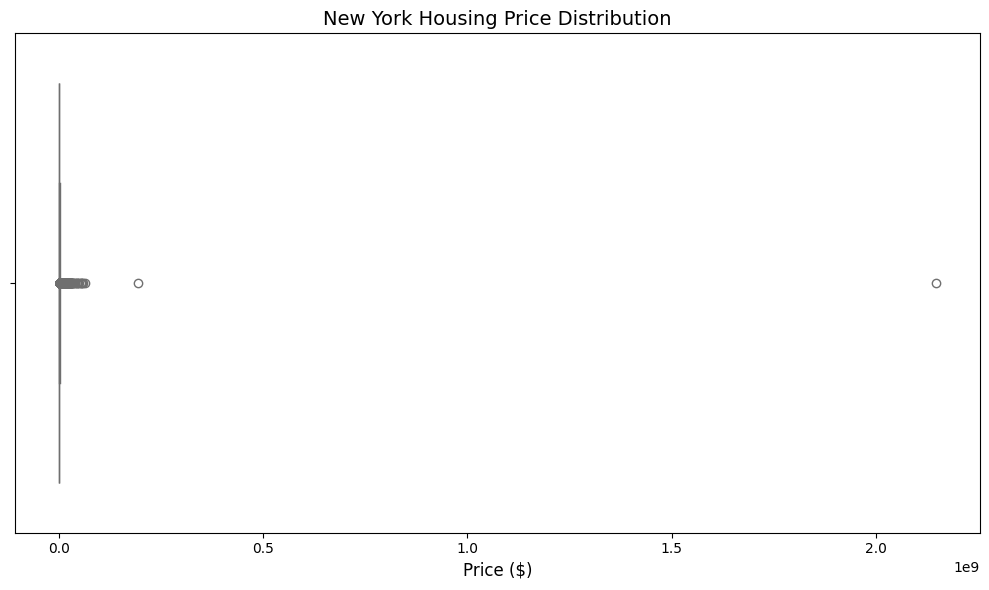

In [774]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [775]:
# Right-skewed price distribution. Should check for error data

In [776]:
df.sort_values(by=['price'], ascending=False).head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude
292,Brokered by ANNE LOPA REAL ESTATE,House for sale,2147483647,7,6,10000.000000,6659-6675 Amboy Rd,"New York, NY 10309","6659-6675 Amboy RdNew York, NY 10309",United States,New York,Richmond County,Staten Island,Amboy Road,"6659 Amboy Rd, Staten Island, NY 10309, USA",40.518484,-74.224418
1,Brokered by Serhant,Condo for sale,195000000,7,10,17545.000000,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
69,Brokered by Sotheby's International Realty - E...,Townhouse for sale,65000000,3,2,15200.000000,4 E 79th St,"New York, NY 10075","4 E 79th StNew York, NY 10075",United States,New York,New York County,New York,East 79th Street,"4 E 79th St, New York, NY 10075, USA",40.776561,-73.963317
1044,Brokered by COMPASS,Co-op for sale,60000000,8,8,2184.207862,960 5th Ave Unit 12,"Manhattan, NY 10075","960 5th Ave Unit 12Manhattan, NY 10075",New York,New York County,New York,Manhattan,960,"960 5th Ave #12, New York, NY 10075, USA",40.775642,-73.964247
138,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,56000000,11,10,24000.000000,9 W 54th St,"New York, NY 10019","9 W 54th StNew York, NY 10019",United States,New York,New York County,New York,West 54th Street,"9 W 54th St, New York, NY 10019, USA",40.761600,-73.976191


In [777]:
# 2147483647 is error input, should be dropped

In [778]:
df = df[df.price < df.price.max()]

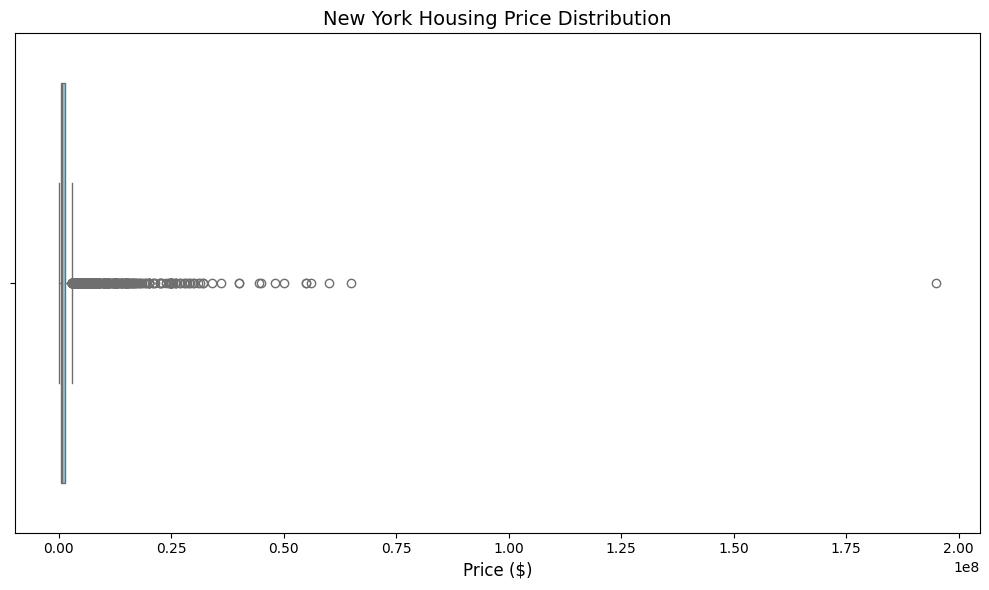

In [779]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [780]:
# Still have an outlier on 195000000$.I checked this property, apparently it is a very famous ultra expensive apartment.
# I will also exclude it

In [781]:
df = df[df.price < df.price.max()]

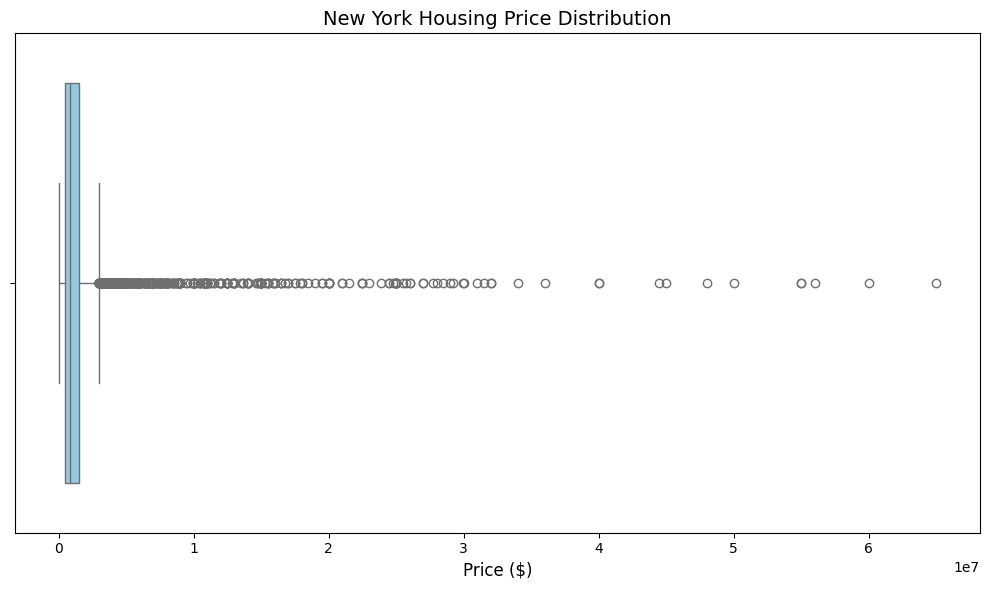

In [782]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df.price, color='skyblue')

# Add informative titles and labels
plt.title('New York Housing Price Distribution', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.tight_layout()

# Display plot
plt.show()

In [783]:
# Now boxplot looks reasonable

In [784]:
# Apply natural log transformation to price
df['log_price'] = np.log(df.price)

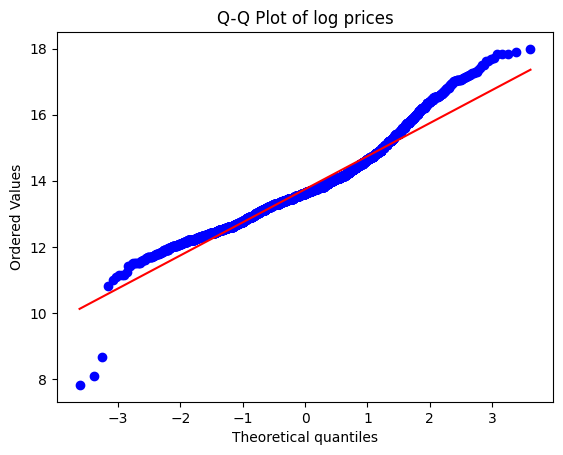

In [785]:
# Identify outliers on Q-Q plot
probplot(df['log_price'], dist="norm", plot=plt)
plt.title("Q-Q Plot of log prices")
plt.show()

In [786]:
# I see three outliers in lower range

In [787]:
df.sort_values('price').head(15)

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude,log_price
305,Brokered by Living NY - Main Office,For sale,2494,2,1,2184.207862,635 W 170th St Apt 4F,"New York, NY 10032","635 W 170th St Apt 4FNew York, NY 10032",New York,New York County,New York,Manhattan,635,"635 W 170th St #4f, New York, NY 10032, USA",40.843406,-73.940795,7.821643
298,Brokered by Living NY - Main Office,For sale,3225,3,1,2184.207862,635 W 170th St Apt 2C,"New York, NY 10032","635 W 170th St Apt 2CNew York, NY 10032",New York,New York County,New York,Manhattan,635,"635 W 170th St #2c, New York, NY 10032, USA",40.843406,-73.940795,8.078688
347,Brokered by Century 21 Realty First,Land for sale,5800,3,2,2184.207862,4515 Avenue N Lot 5,"Brooklyn, NY 11234","4515 Avenue N Lot 5Brooklyn, NY 11234",New York,Kings County,Brooklyn,Flatlands,4515,"4515 Avenue N #5, Brooklyn, NY 11234, USA",40.618915,-73.931211,8.665613
449,Brokered by Morris Park Realty Group,Co-op for sale,49500,3,2,800.000000,150 City Island Ave Unit E3,"Bronx, NY 10464","150 City Island Ave Unit E3Bronx, NY 10464",New York,Bronx County,The Bronx,City Island,150,"150 City Island Ave #3e, Bronx, NY 10464, USA",40.843284,-73.784603,10.809728
950,Brokered by COMPASS,Condo for sale,60000,3,1,445.000000,2 E 55th St Unit 809W35,"Manhattan, NY 10022","2 E 55th St Unit 809W35Manhattan, NY 10022",New York,New York County,New York,Manhattan,2,"2 E 55th St 809 35, New York, NY 10022, USA",40.761398,-73.974613,11.002100
184,Brokered by All American Realty Management,For sale,65000,3,1,230.000000,1287266 45 Madison St Unit 1,"Manhattan, NY 10038","1287266 45 Madison St Unit 1Manhattan, NY 10038",New York,New York County,New York,Manhattan,45,"45 Madison St #1, New York, NY 10038, USA",40.712070,-73.998326,11.082143
3,Brokered by COMPASS,Condo for sale,69000,3,1,445.000000,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,11.141862
243,Brokered by BESMATCH REAL ESTATE,Co-op for sale,69000,1,1,850.000000,1185 Anderson Ave Apt 2E,"Bronx, NY 10452","1185 Anderson Ave Apt 2EBronx, NY 10452",New York,Bronx County,The Bronx,Highbridge,1185,"1185 Anderson Ave #2e, Bronx, NY 10452, USA",40.836662,-73.923959,11.141862
129,Brokered by Utopia Real Estate,Co-op for sale,69900,2,1,700.000000,61 Edgewater Park Unit B,"Bronx, NY 10465","61 Edgewater Park Unit BBronx, NY 10465",United States,New York,Bronx County,The Bronx,Edgewater Park,"61 Edgewater Park, Bronx, NY 10465, USA",40.822499,-73.811157,11.154821
3835,Brokered by Prestige Homes Ny Inc,Land for sale,75000,3,2,2184.207862,199th St,"Saint Albans, NY 11412","199th StSaint Albans, NY 11412",11412,United States,New York,Queens County,Jamaica,"199th St, Jamaica, NY 11412, USA",40.694216,-73.753090,11.225243


In [788]:
# Data cleaning:
# - $2,494 and $3,225 (Manhattan apartments) - Below realistic thresholds
# - $5,800 (land) - Far below NYC market minimums

df = df[df.price>10000]

In [789]:
# Reset index after cleaning
df = df.reset_index(drop=True)

<Axes: xlabel='price', ylabel='type'>

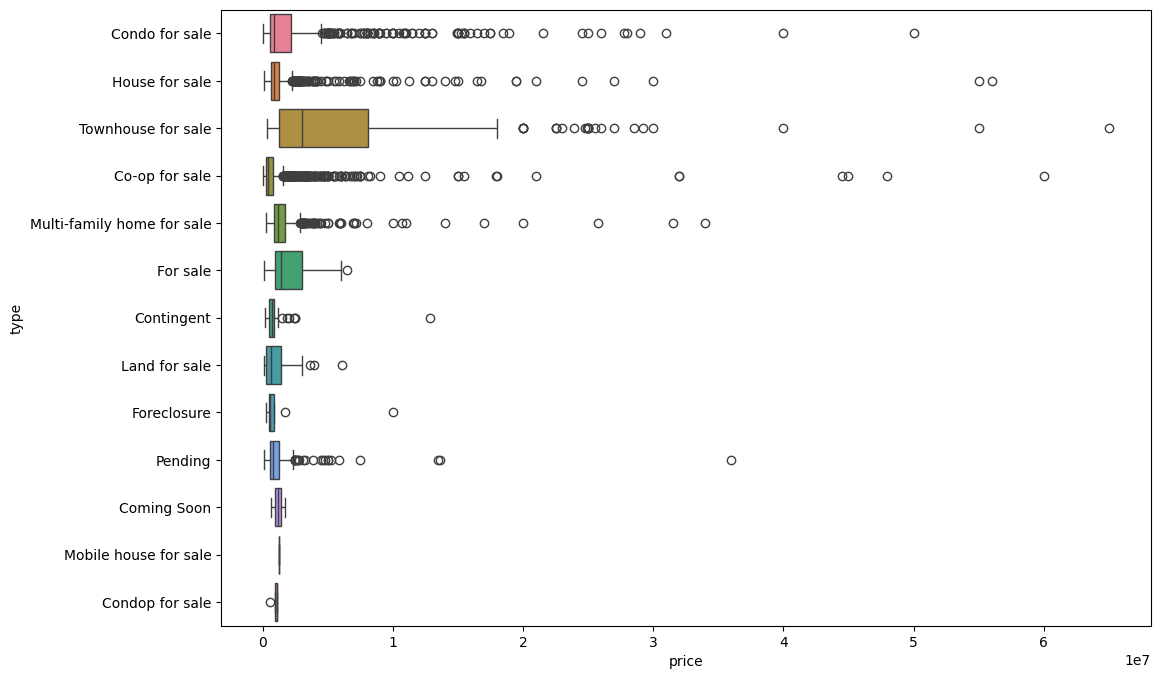

In [790]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='type', hue='type')

In [791]:
# Here we can see that we have a stratification of the market, apparently townhouses are considered more as luxurious property

In [792]:
# Calculate 90th percentile price thresholds by property type to identify price ceilings 
# for the top 10% of each property type and understand price distribution characteristics across categories

type_thresholds = df.groupby('type')['price'].quantile(0.9) 

In [793]:
print('0.90 quantile by type of houses')
print(type_thresholds.sort_values())
print('mean:',type_thresholds.mean())
print('median:',type_thresholds.median())

0.90 quantile by type of houses
type
Condop for sale                1111500.0
Contingent                     1119400.0
Mobile house for sale          1288000.0
Foreclosure                    1494900.0
Coming Soon                    1590400.0
Co-op for sale                 2150000.0
Pending                        2290400.0
House for sale                 2399600.0
Multi-family home for sale     2499000.0
Land for sale                  2774975.0
For sale                       4599700.0
Condo for sale                 5250000.0
Townhouse for sale            15892000.0
Name: price, dtype: float64
mean: 3419990.384615385
median: 2290400.0


In [794]:
# We again observe that the townhouse category is significantly different

In [795]:
# Calculate 50th percentile price thresholds by property type to assess entry - middle division point

type_thresholds_50 = df.groupby('type')['price'].quantile(0.5)
print('0.50 quantile by type of houses')
print(type_thresholds_50.sort_values())
print('mean:',type_thresholds_50.mean())
print('median:',type_thresholds_50.median())

0.50 quantile by type of houses
type
Co-op for sale                 425000.0
Foreclosure                    592450.0
Land for sale                  675000.0
Contingent                     689900.0
Pending                        825000.0
House for sale                 858000.0
Condo for sale                 880000.0
Condop for sale               1072500.0
Coming Soon                   1172000.0
Multi-family home for sale    1199000.0
Mobile house for sale         1288000.0
For sale                      1420000.0
Townhouse for sale            2995000.0
Name: price, dtype: float64
mean: 1083988.4615384615
median: 880000.0


In [796]:
# Threshold set at $3,000,000 based on central tendency analysis of the 0.90 quantile prices by property type
# And for entry - middle division set at $1,000,000
# Probable downside is that townhouses could be undervalued by modelling

# Also create cateforical price segment column for clear visual analysis (NOT SUITABLE FOR MODELLING)
df['price_segment'] = pd.cut(
    df['price'],
    bins=[0, 1_000_000, 3_000_000, 12_000_000, np.inf],
    labels=['entry', 'mid', 'upper', 'luxury'],
    include_lowest=True,
    right=True
)

<Axes: xlabel='log_price', ylabel='type'>

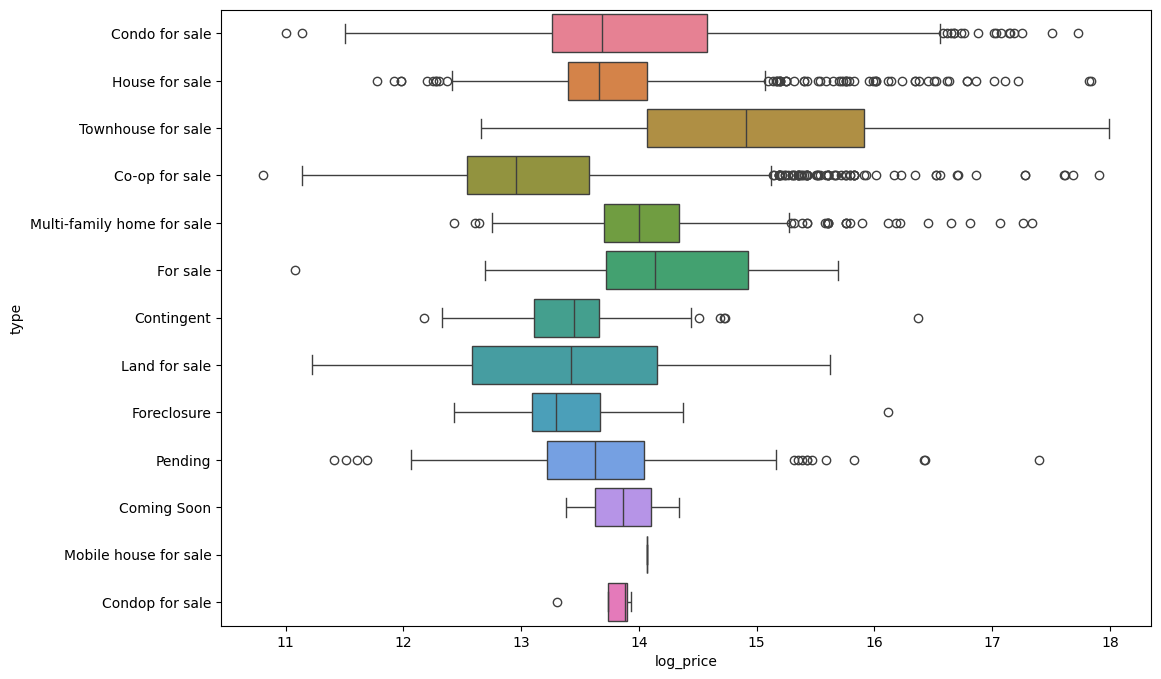

In [797]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='log_price', y='type', hue='type')

<Axes: xlabel='log_price', ylabel='Count'>

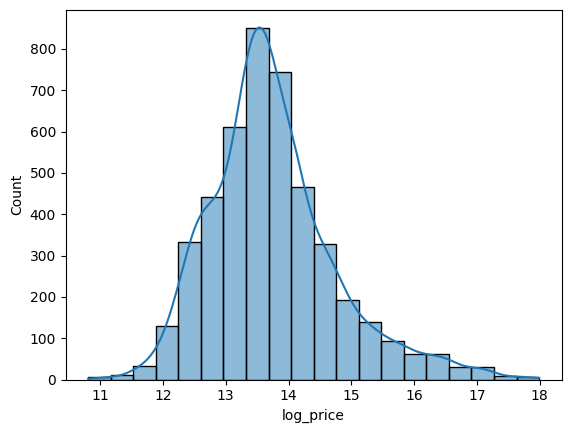

In [798]:
sns.histplot(df.log_price, bins=20, kde=True)

In [799]:
# log_price looks quite normal

In [800]:
# I see three outliers in lower range

In [801]:
df.sort_values('price').head()

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude,log_price,price_segment
444,Brokered by Morris Park Realty Group,Co-op for sale,49500,3,2,800.0,150 City Island Ave Unit E3,"Bronx, NY 10464","150 City Island Ave Unit E3Bronx, NY 10464",New York,Bronx County,The Bronx,City Island,150,"150 City Island Ave #3e, Bronx, NY 10464, USA",40.843284,-73.784603,10.809728,entry
945,Brokered by COMPASS,Condo for sale,60000,3,1,445.0,2 E 55th St Unit 809W35,"Manhattan, NY 10022","2 E 55th St Unit 809W35Manhattan, NY 10022",New York,New York County,New York,Manhattan,2,"2 E 55th St 809 35, New York, NY 10022, USA",40.761398,-73.974613,11.002100,entry
183,Brokered by All American Realty Management,For sale,65000,3,1,230.0,1287266 45 Madison St Unit 1,"Manhattan, NY 10038","1287266 45 Madison St Unit 1Manhattan, NY 10038",New York,New York County,New York,Manhattan,45,"45 Madison St #1, New York, NY 10038, USA",40.712070,-73.998326,11.082143,entry
242,Brokered by BESMATCH REAL ESTATE,Co-op for sale,69000,1,1,850.0,1185 Anderson Ave Apt 2E,"Bronx, NY 10452","1185 Anderson Ave Apt 2EBronx, NY 10452",New York,Bronx County,The Bronx,Highbridge,1185,"1185 Anderson Ave #2e, Bronx, NY 10452, USA",40.836662,-73.923959,11.141862,entry
2,Brokered by COMPASS,Condo for sale,69000,3,1,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,11.141862,entry


In [802]:
# Data cleaning:
# - $2,494 and $3,225 (Manhattan apartments) - Below realistic thresholds
# - $5,800 (land) - Far below NYC market minimums

df = df[df.price>10000]

In [803]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [804]:
1 - len(df)/original_length

0.0010900370612600963

In [805]:
# dropped only 0.1% of data

## Other variables distribution

In [806]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'address', 'state', 'main_address', 'administrative_area_level_2',
       'locality', 'sublocality', 'street_name', 'long_name',
       'formatted_address', 'latitude', 'longitude', 'log_price',
       'price_segment'],
      dtype='object')

### _Brokertitle_

In [807]:
df.brokertitle.value_counts()

brokertitle
Brokered by COMPASS                              435
Brokered by Douglas Elliman - 575 Madison Ave    109
Brokered by Brown Harris Stevens                  93
Brokered by Corcoran East Side                    86
Brokered by RE MAX Edge                           75
                                                ... 
Brokered by Tworealestate Llc                      1
Brokered by Blue Key Real Estate Brokerage         1
Brokered by Douglas Elliman - New Hyde Park        1
Brokered by Renken Realty LLC                      1
Brokered by Contact Realty Ii Corp                 1
Name: count, Length: 1035, dtype: int64

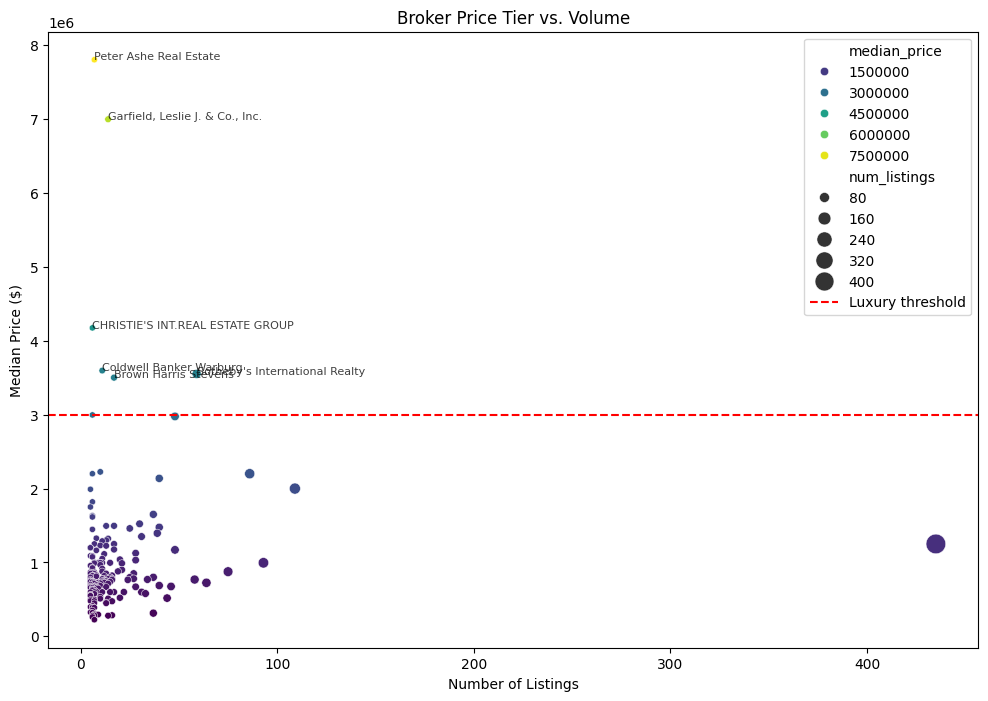

In [808]:
# Get broker stats: count and median price
broker_stats = df.groupby('brokertitle').agg(
    num_listings=('price', 'count'),
    median_price=('price', 'median'),
    max_price=('price', 'max')
).sort_values('median_price', ascending=False)

# Filter brokers with ≥5 listings (avoid noise)
broker_stats = broker_stats[broker_stats['num_listings'] >= 5]

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=broker_stats,
    x='num_listings',
    y='median_price',
    hue='median_price',
    palette='viridis',
    size='num_listings',
    sizes=(20, 200)
)

# Annotate top luxury brokers
top_luxury = broker_stats[broker_stats['median_price'] > 3_000_000]  # Adjust thresholdb
for idx, row in top_luxury.iterrows():
    plt.annotate(
        idx.replace('Brokered by ', '').split('-')[0].strip(),
        (row['num_listings'], row['median_price']),
        fontsize=8, alpha=0.75
    )

#plt.xscale('log')  # Better visibility for wide-ranging counts
plt.xlabel('Number of Listings')
plt.ylabel('Median Price ($)')
plt.title('Broker Price Tier vs. Volume')
plt.axhline(y=3_000_000, color='red', linestyle='--', label='Luxury threshold') 
plt.legend()
plt.show()

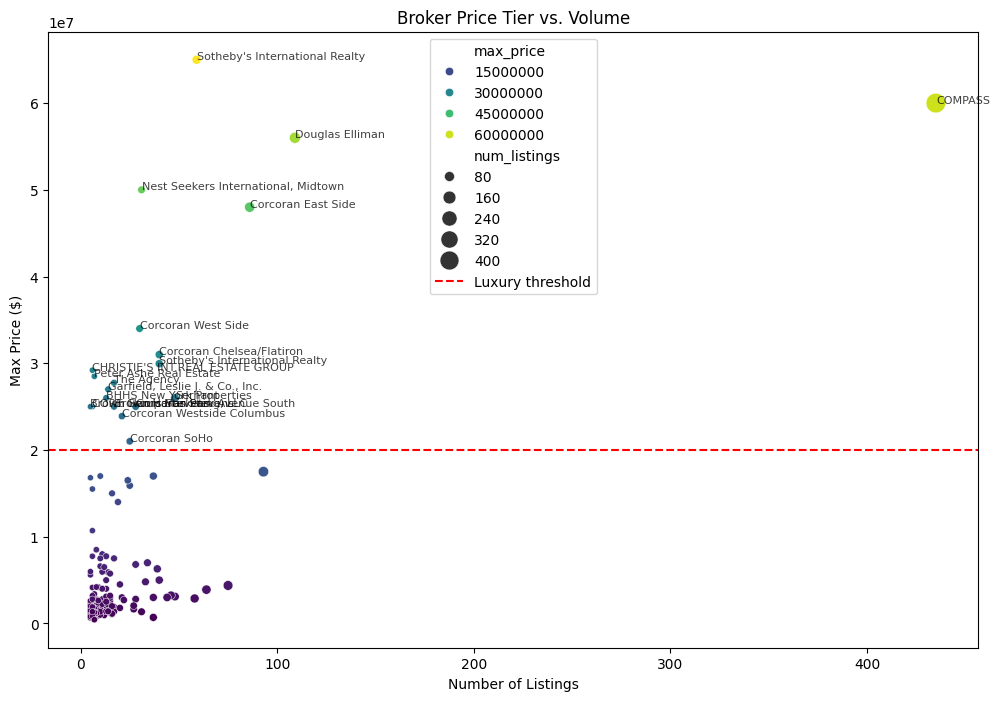

In [809]:
# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=broker_stats,
    x='num_listings',
    y='max_price',
    hue='max_price',
    palette='viridis',
    size='num_listings',
    sizes=(20, 200)
)

# Annotate top luxury brokers
top_luxury = broker_stats[broker_stats['max_price'] > 20_000_000]  # Adjust thresholdb
for idx, row in top_luxury.iterrows():
    plt.annotate(
        idx.replace('Brokered by ', '').split('-')[0].strip(),
        (row['num_listings'], row['max_price']),
        fontsize=8, alpha=0.75
    )

#plt.xscale('log')  # Better visibility for wide-ranging counts
plt.xlabel('Number of Listings')
plt.ylabel('Max Price ($)')
plt.title('Broker Price Tier vs. Volume')
plt.axhline(y=20_000_000, color='red', linestyle='--', label='Luxury threshold') 
plt.legend()
plt.show()

In [810]:
broker_stats.head(10)

,num_listings,median_price,max_price
brokertitle,,,
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,7,7800000.0,28500000
"Brokered by Garfield, Leslie J. & Co., Inc.",14,6995000.0,27000000
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,6,4172500.0,29200000
Brokered by Coldwell Banker Warburg,11,3595000.0,7995000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
Brokered by Brown Harris Stevens - 1926 Broadway,17,3500000.0,25000000
"Brokered by CORE Group Marketing, LLC",6,2994999.5,25000000
Brokered by Serhant,48,2974999.5,26000000
Brokered by R New York,10,2225000.0,16995000


In [811]:
broker_stats.sort_values(by='num_listings', ascending=False).head(10)

,num_listings,median_price,max_price
brokertitle,,,
Brokered by COMPASS,435,1250000.0,60000000
Brokered by Douglas Elliman - 575 Madison Ave,109,1999000.0,56000000
Brokered by Brown Harris Stevens,93,995000.0,17500000
Brokered by Corcoran East Side,86,2200000.0,48000000
Brokered by RE MAX Edge,75,875000.0,4380000
Brokered by Winzone Realty Inc,64,724500.0,3900000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
Brokered by E Realty International Corp,58,768500.0,2880000
Brokered by Serhant,48,2974999.5,26000000


In [812]:
df.sort_values(by='price', ascending=False).head(15)

,brokertitle,type,price,beds,bath,propertysqft,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address,latitude,longitude,log_price,price_segment
68,Brokered by Sotheby's International Realty - E...,Townhouse for sale,65000000,3,2,15200.000000,4 E 79th St,"New York, NY 10075","4 E 79th StNew York, NY 10075",United States,New York,New York County,New York,East 79th Street,"4 E 79th St, New York, NY 10075, USA",40.776561,-73.963317,17.989898,luxury
1039,Brokered by COMPASS,Co-op for sale,60000000,8,8,2184.207862,960 5th Ave Unit 12,"Manhattan, NY 10075","960 5th Ave Unit 12Manhattan, NY 10075",New York,New York County,New York,Manhattan,960,"960 5th Ave #12, New York, NY 10075, USA",40.775642,-73.964247,17.909855,luxury
137,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,56000000,11,10,24000.000000,9 W 54th St,"New York, NY 10019","9 W 54th StNew York, NY 10019",United States,New York,New York County,New York,West 54th Street,"9 W 54th St, New York, NY 10019, USA",40.761600,-73.976191,17.840862,luxury
3,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2,14175.000000,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856,17.822844,luxury
97,Brokered by Douglas Elliman - 575 Madison Ave,House for sale,55000000,8,8,12000.000000,25 Riverside Dr,"New York, NY 10023","25 Riverside DrNew York, NY 10023",United States,New York,New York County,New York,Riverside Drive,"25 Riverside Dr, New York, NY 10023, USA",40.782238,-73.984632,17.822844,luxury
602,"Brokered by Nest Seekers International, Midtown",Condo for sale,50000000,6,6,6569.000000,100 Vandam St Apt 20A,"New York, NY 10013","100 Vandam St Apt 20ANew York, NY 10013",New York,New York County,New York,Manhattan,100,"100 Vandam St #20a, New York, NY 10013, USA",40.726633,-74.008832,17.727534,luxury
1401,Brokered by Corcoran East Side,Co-op for sale,48000000,5,2,2184.207862,740 Park Ave # 4 & 5B,"New York, NY 10021","740 Park Ave # 4 & 5BNew York, NY 10021",New York,New York County,New York,Manhattan,740,"740 Park Ave #5, New York, NY 10021, USA",40.770752,-73.964528,17.686712,luxury
3255,Brokered by Sotheby's International Realty - E...,Co-op for sale,45000000,5,2,2184.207862,4 E 66th St Fl 7,"New York, NY 10065","4 E 66th St Fl 7New York, NY 10065",New York,New York County,New York,Manhattan,4,"4 E 66th St Fl 7, New York, NY 10065, USA",40.768301,-73.969734,17.622173,luxury
3427,Brokered by Sotheby's International Realty - E...,Co-op for sale,44500000,5,6,2184.207862,2 E 67th St Fl 9,"New York, NY 10065","2 E 67th St Fl 9New York, NY 10065",New York,New York County,New York,Manhattan,2,"2 E 67th St Fl 9, New York, NY 10065, USA",40.768973,-73.969136,17.611000,luxury
1413,Brokered by Douglas Elliman - New Development,Condo for sale,40000000,5,6,7488.000000,111 Murray St Ph 2,"New York, NY 10007","111 Murray St Ph 2New York, NY 10007",New York,New York County,New York,Manhattan,111,"111 Murray St Ph 2, New York, NY 10007, USA",40.715351,-74.012844,17.504390,luxury


In [813]:
selected_brokers = [
    'COMPASS',
    'Sotheby\'s International Realty - East Side Manhattan Brokerage',
    'Peter Ashe Real Estate- Peter Ashe Real Estate',
    'Douglas Elliman - 575 Madison Ave',
    'Corcoran East Side',
    'Serhant',
    'Garfield, Leslie J. & Co., Inc.',
    "CHRISTIE'S INT.REAL ESTATE GROUP",
    'Coldwell Banker Warburg',
]

# Filter data
plot_data = df[df['brokertitle'].str.contains('|'.join(selected_brokers))]

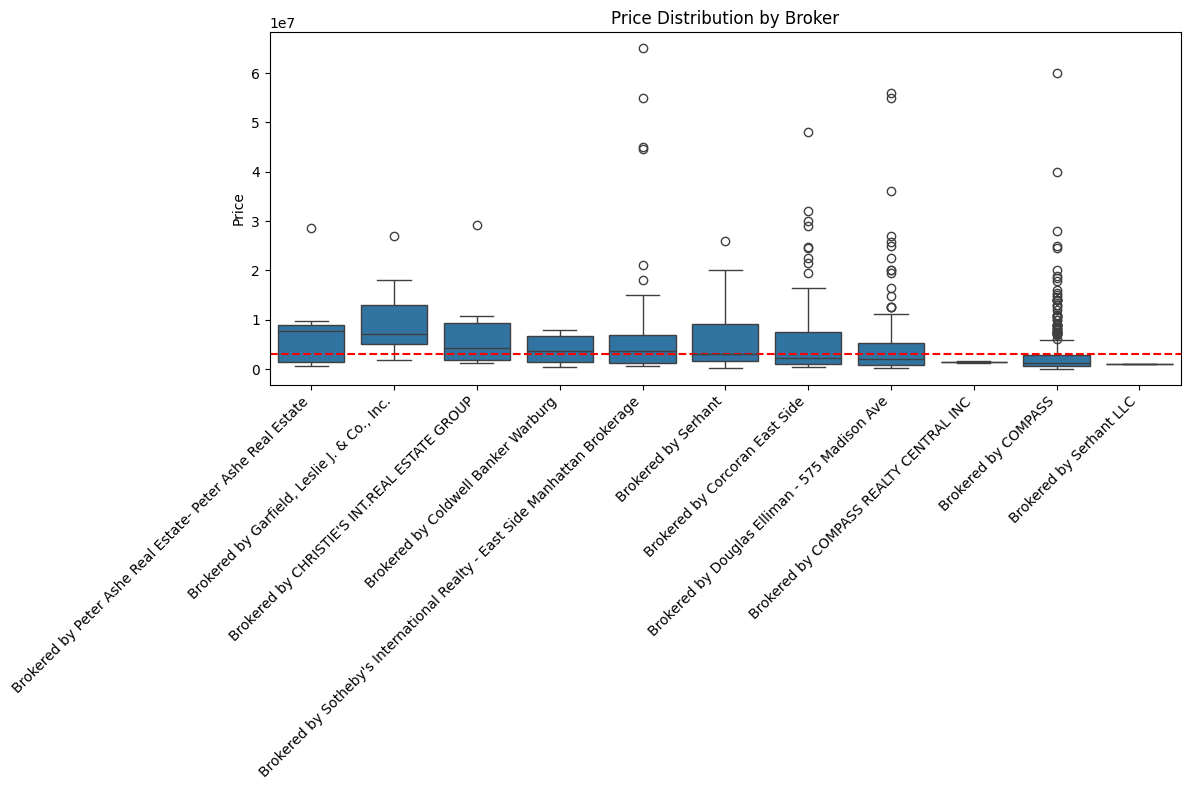

In [814]:
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=plot_data,
    x='brokertitle',
    y='price',
    order=plot_data.groupby('brokertitle')['price'].median().sort_values(ascending=False).index,
    showfliers=True  # Hide outliers initially
)

# Add context
plt.axhline(y=3_000_000, color='red', linestyle='--', label='Luxury threshold')
plt.xticks(rotation=45, ha='right')
#plt.yscale('log')  # Critical for NYC price ranges
plt.title('Price Distribution by Broker')
plt.ylabel('Price')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [815]:
broker_stats

,num_listings,median_price,max_price
brokertitle,,,
Brokered by Peter Ashe Real Estate- Peter Ashe Real Estate,7,7800000.0,28500000
"Brokered by Garfield, Leslie J. & Co., Inc.",14,6995000.0,27000000
Brokered by CHRISTIE'S INT.REAL ESTATE GROUP,6,4172500.0,29200000
Brokered by Coldwell Banker Warburg,11,3595000.0,7995000
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage,59,3550000.0,65000000
...,...,...,...
Brokered by RE/MAX City Square,7,284888.0,1268000
Brokered by Keller Williams Realty Liberty,14,279250.0,1399000
Brokered by Goldstone N Y Realty Llc,6,278500.0,880000


In [816]:
# Add new features based on brokertitle column (See Feature Engineering section)

### _Type_

In [817]:
df.type.value_counts()

type
Co-op for sale                1388
House for sale                 965
Condo for sale                 841
Multi-family home for sale     699
Townhouse for sale             288
Pending                        229
Contingent                      87
Land for sale                   46
For sale                        18
Foreclosure                     14
Condop for sale                  4
Coming Soon                      2
Mobile house for sale            1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='type'>

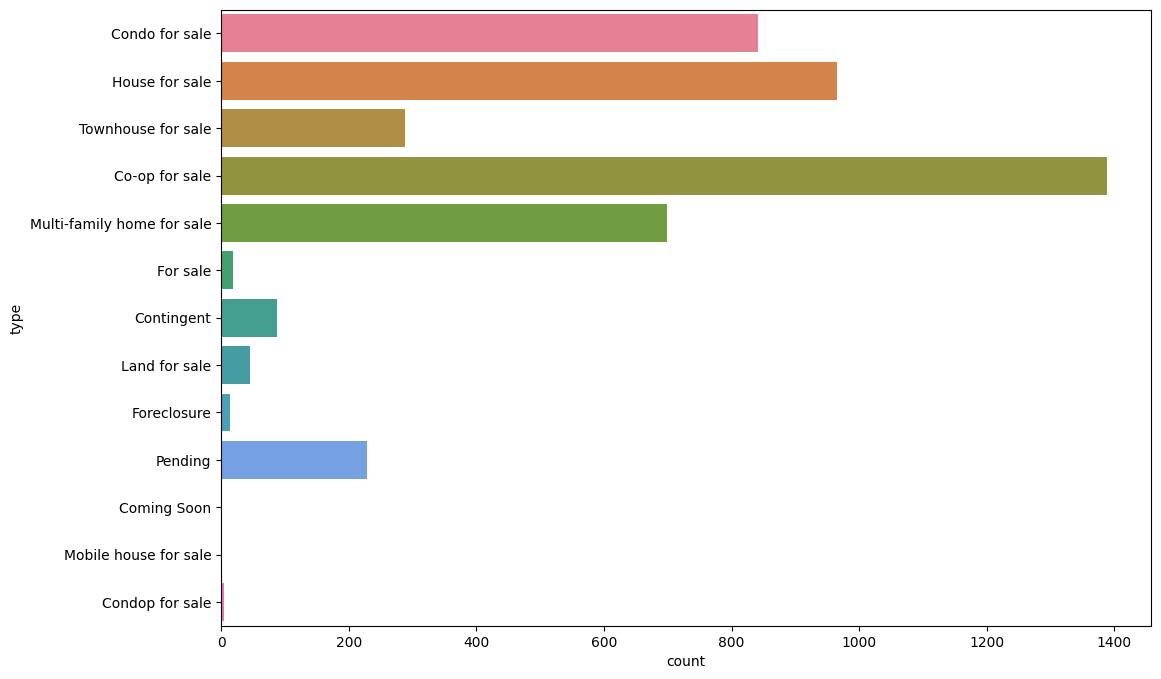

In [818]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='type', hue='type')

In [819]:
# Identify types to potentially consolidate
rare_types = df['type'].value_counts()[df['type'].value_counts() < 20].index
print(f"Rare types (<20 listings): {list(rare_types)}")

Rare types (<20 listings): ['For sale', 'Foreclosure', 'Condop for sale', 'Coming Soon', 'Mobile house for sale']


In [820]:
# Group rare types in other category
eda_features.append('eda_type_clean')
df['eda_type_clean'] = np.where(df['type'].isin(rare_types), 'Other', df['type'])

In [821]:
# Averages by type
df.groupby('eda_type_clean')[['price', 'beds', 'bath', 'propertysqft', ]].mean().sort_values('price', ascending=False)

,price,beds,bath,propertysqft
eda_type_clean,,,,
Townhouse for sale,6.406234e+06,5.020833,3.805556,3887.512776
Condo for sale,2.387024e+06,2.322235,1.985731,1552.737999
Other,1.676593e+06,3.589744,2.333333,2203.941082
Multi-family home for sale,1.666781e+06,6.261803,3.907010,3210.209600
House for sale,1.565096e+06,3.730570,2.495337,2246.429021
Pending,1.362436e+06,3.179039,2.218341,2076.871914
Land for sale,1.128747e+06,3.000000,2.000000,2157.377256
Co-op for sale,1.113426e+06,1.984870,1.436599,1658.496424
Contingent,8.886932e+05,3.218391,2.172414,1782.559344


In [822]:
# Here we also can see that townhouse type differs from others

<Axes: xlabel='price', ylabel='eda_type_clean'>

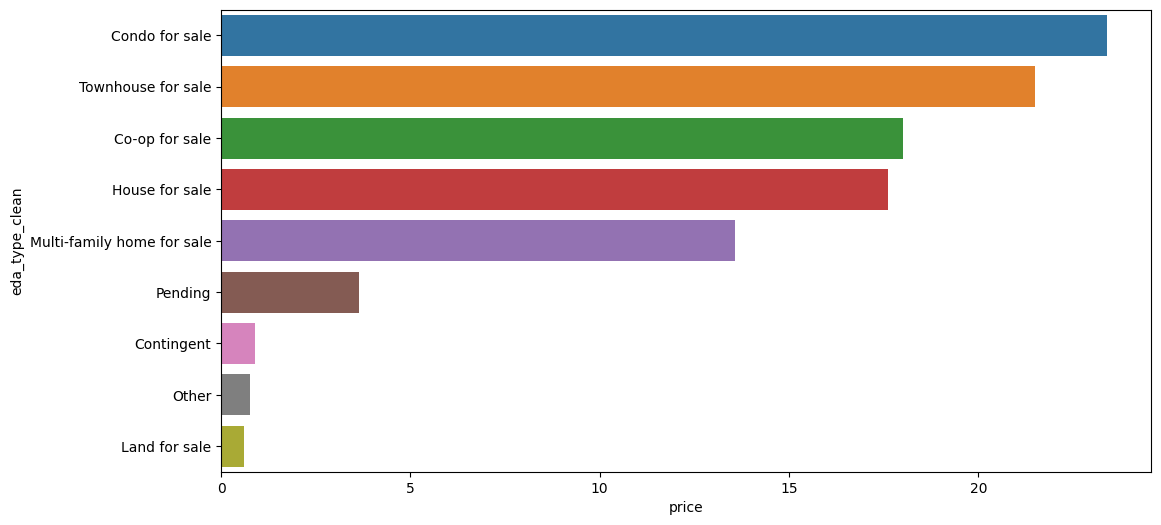

In [823]:
# Calculate market share by types
market_share = (df.groupby('eda_type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='eda_type_clean',
            hue='eda_type_clean')

In [824]:
market_share

eda_type_clean
Condo for sale                23.397448
Townhouse for sale            21.503595
Co-op for sale                18.012197
House for sale                17.602897
Multi-family home for sale    13.579116
Pending                        3.636364
Contingent                     0.901129
Other                          0.762093
Land for sale                  0.605160
Name: price, dtype: float64

In [825]:
# Additionally consolidate rare property types (<1% market share) into 'Other' category
df['eda_type_clean'] = np.where(df['eda_type_clean'].isin(market_share[market_share < 1.0].index),'Other', df['eda_type_clean'])

<Axes: xlabel='price', ylabel='eda_type_clean'>

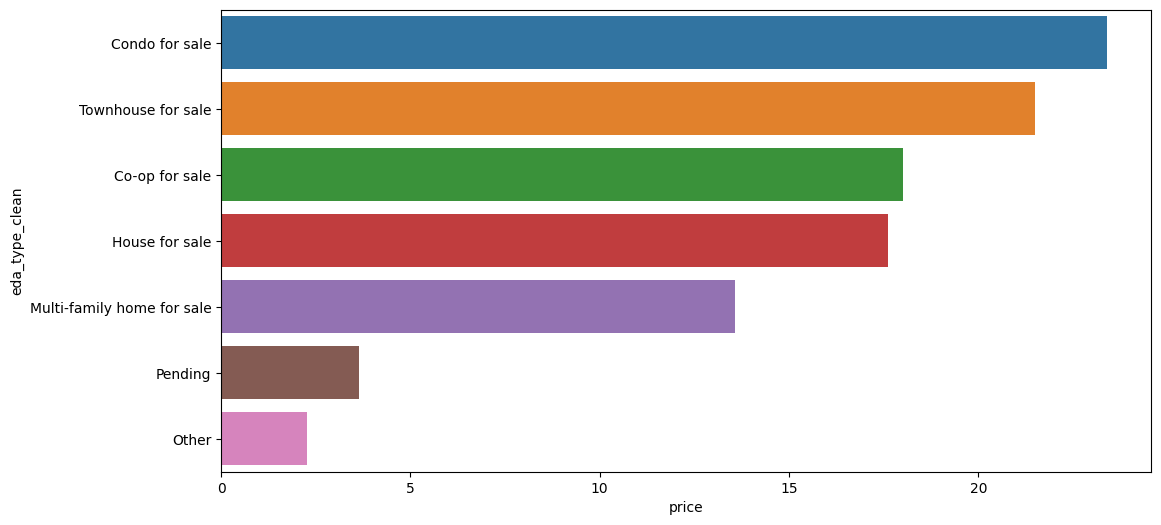

In [826]:
# Calculate market share by types
market_share = (df.groupby('eda_type_clean')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='eda_type_clean',
            hue='eda_type_clean')

<Axes: xlabel='price', ylabel='eda_type_clean'>

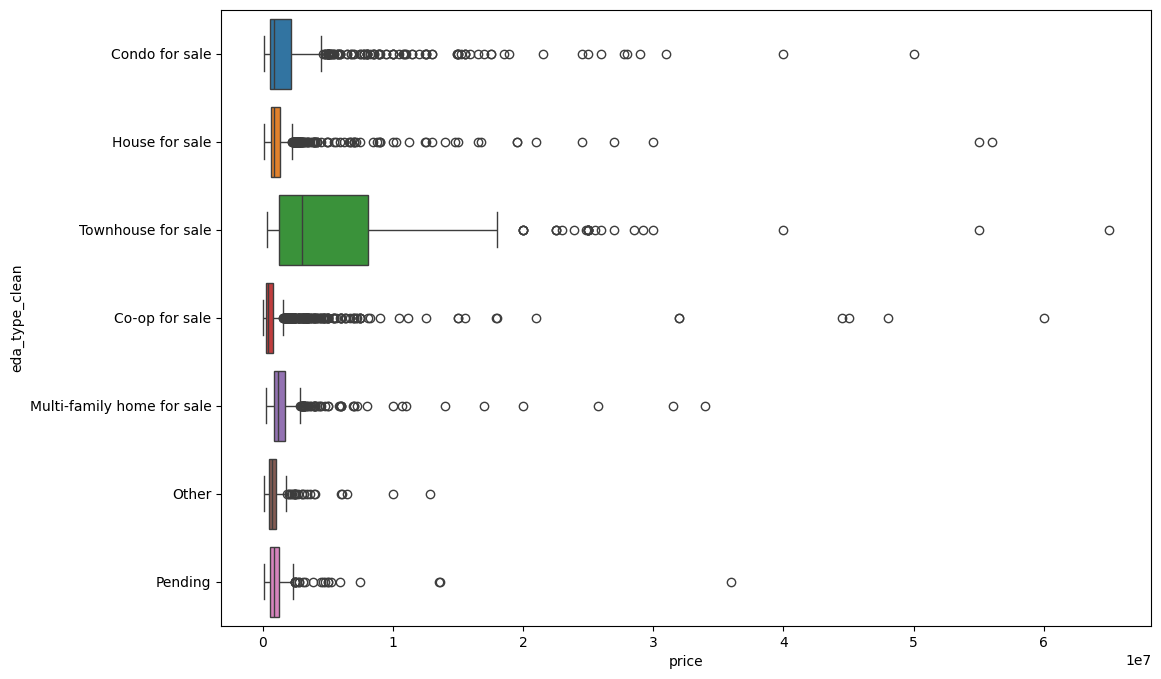

In [827]:
# Create price distribution visualization by property type
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='eda_type_clean', hue='eda_type_clean')

### _Beds_

<Axes: xlabel='count', ylabel='beds'>

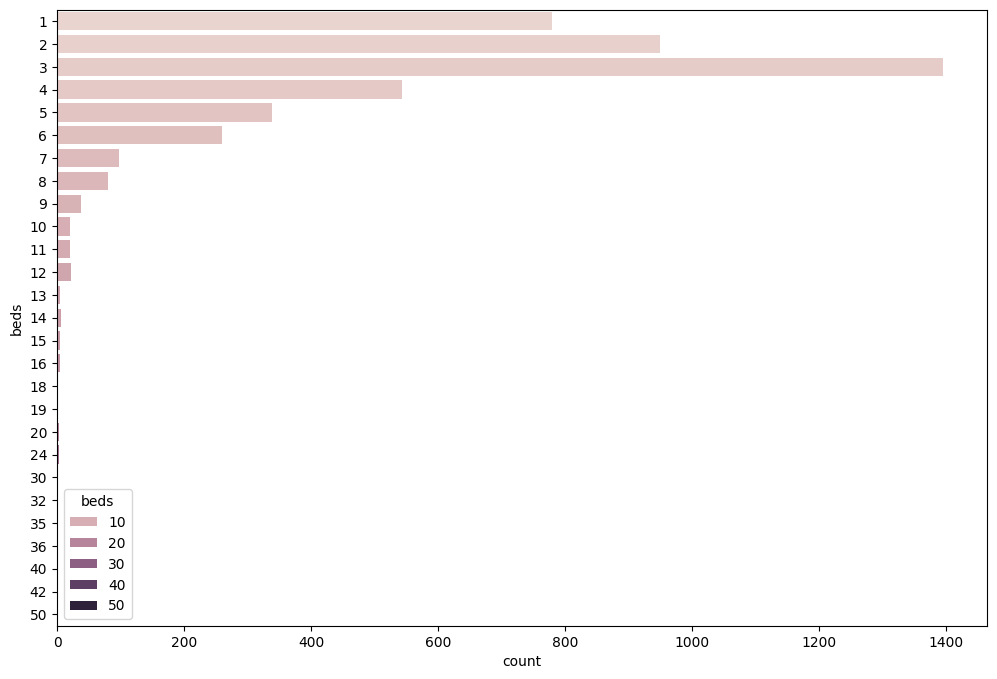

In [828]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='beds', hue='beds')

In [829]:
# Here we also have a skewed distribution

Text(0.5, 1.0, 'Price Distribution by Bedroom Count')

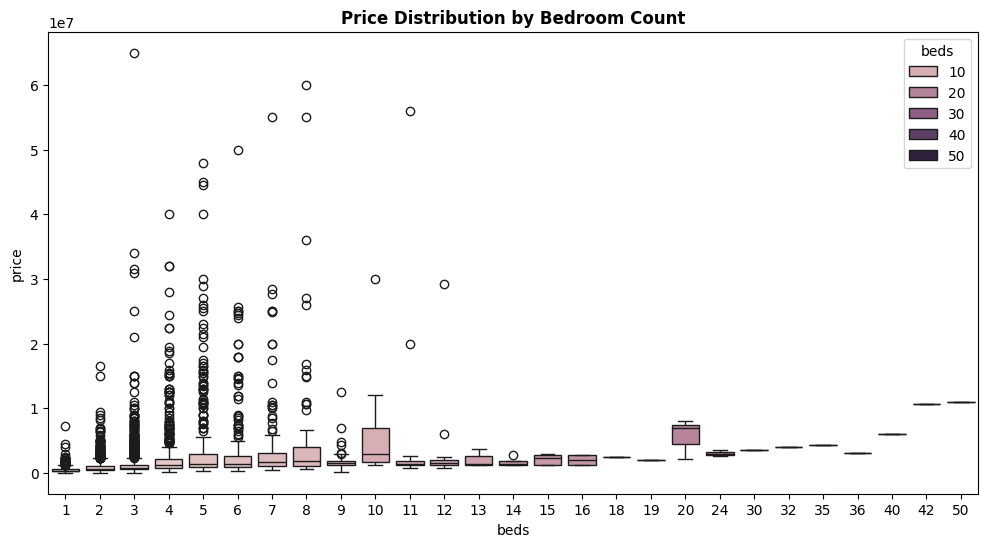

In [830]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=True,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [831]:
# Market doesn't following beds after 10-12 bedrooms. Most high priced properties have 1-8 bedrooms. So it's probably a good idea divide those groups

Text(0.5, 1.0, 'Price Distribution by Bedroom Count')

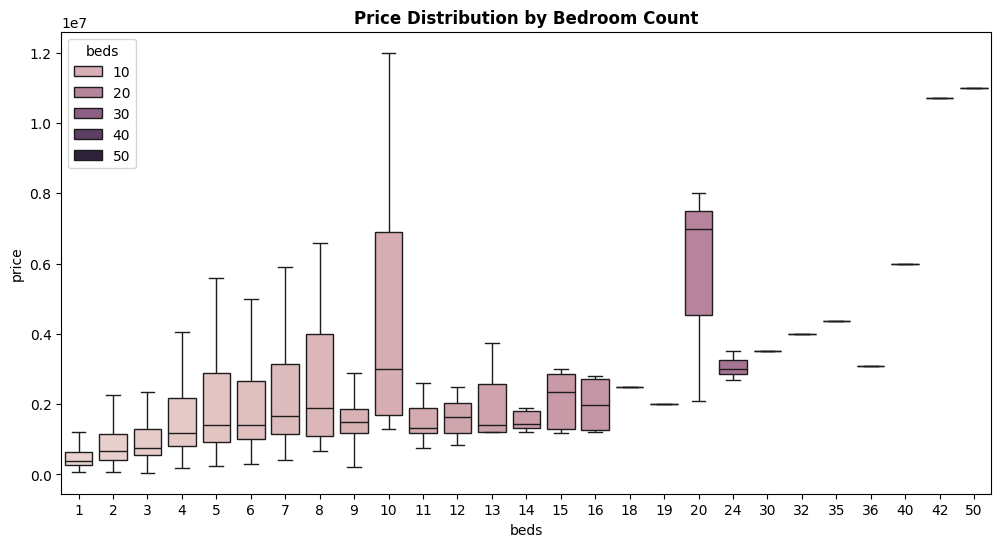

In [832]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='beds',
    y='price',
    showfliers=False,
    hue='beds'
)
#plt.yscale('log')
plt.title('Price Distribution by Bedroom Count', fontweight='bold')

In [833]:
# Here we also see linear relation beds - price up to 10 bedrooms

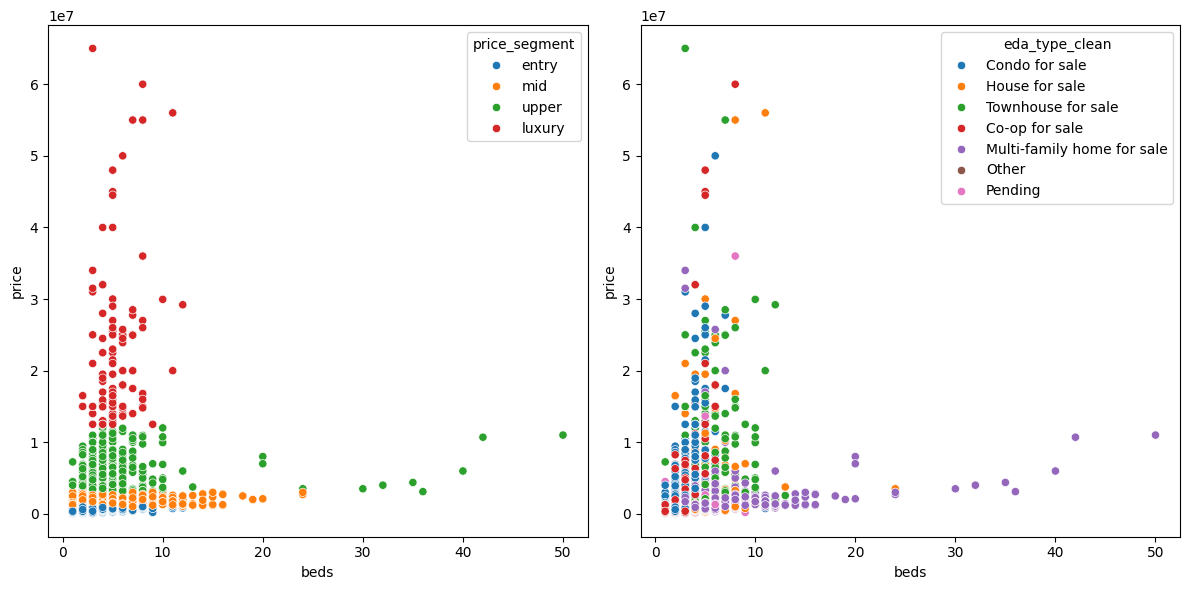

In [834]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.scatterplot(data=df, x='beds', y='price', hue='price_segment')

plt.subplot(1,2,2)
sns.scatterplot(data=df, x='beds', y='price', hue='eda_type_clean')

plt.tight_layout()

In [835]:
# Those properties with high bedroom number are mostly multi-family homes

<Axes: xlabel='beds', ylabel='bath'>

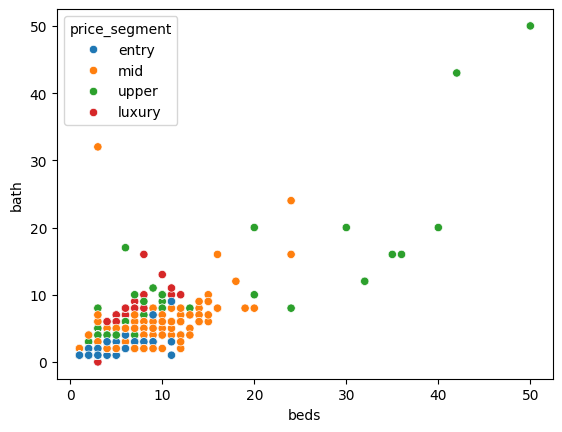

In [836]:
sns.scatterplot(data=df, x='beds', y='bath', hue='price_segment')

In [837]:
# ok, so no luxurios entries in high number bedroom segment

<Axes: xlabel='beds', ylabel='count'>

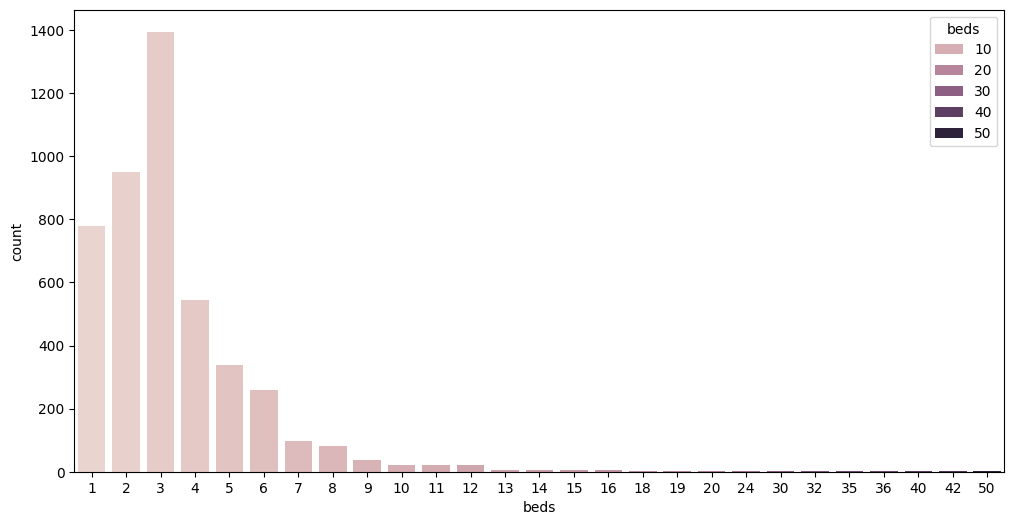

In [838]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='beds', hue='beds')

In [839]:
df['beds'].quantile(0.99)

np.float64(12.0)

In [840]:
# So 12 bedrooms seems as a good threshold. Feature will be added in Feature Engineering section

<Axes: xlabel='beds', ylabel='price'>

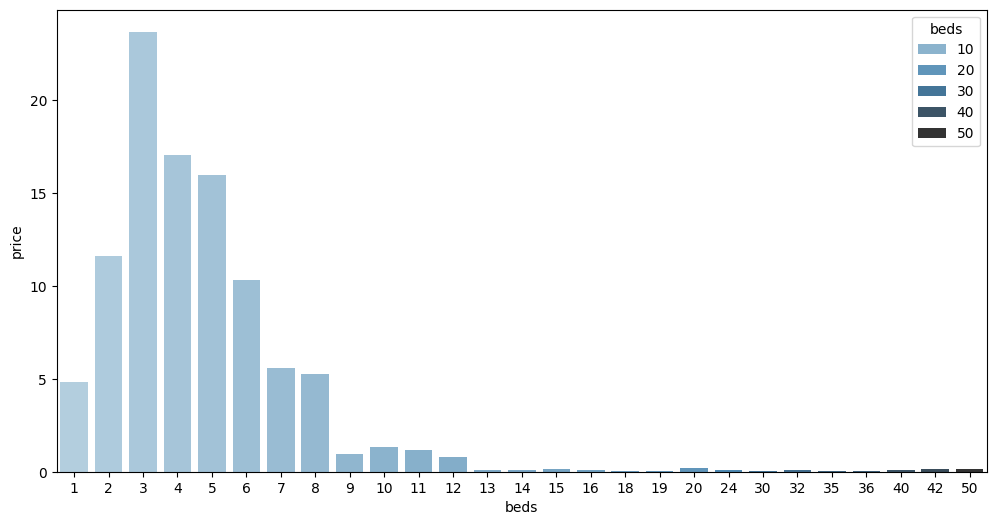

In [841]:
# Calculate market share by bedrooms
market_share = (df.groupby('beds')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

<Axes: xlabel='beds', ylabel='price'>

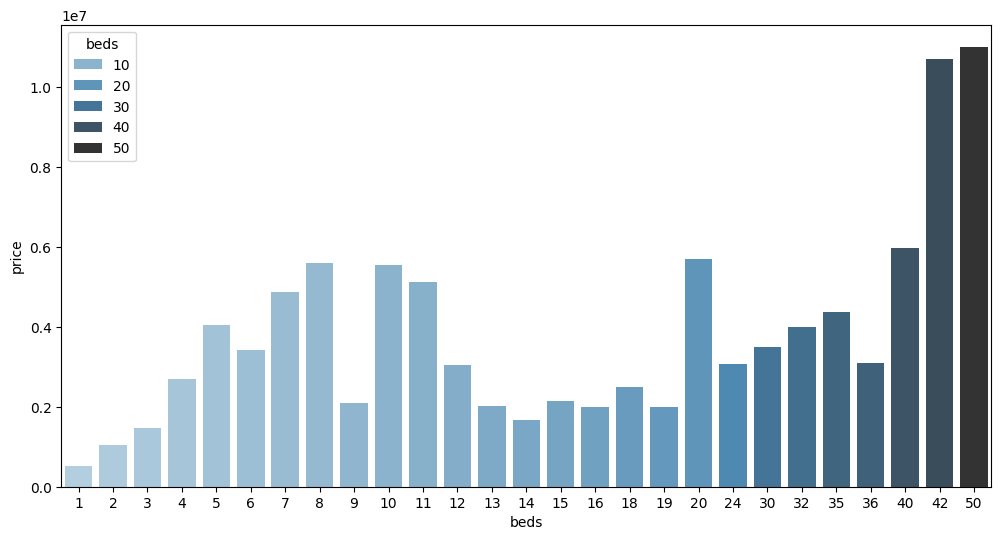

In [842]:
# Mean price dinamic based on number of bedrooms
market_share = (df.groupby('beds')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='beds',
            hue='beds',
            palette='Blues_d')

In [843]:
# The 1-6 bedroom homes aren’t the most expensive, but they dominate the market – they make up nearly 90% of listings.

In [844]:
df['log_beds'] = np.log1p(df['beds'])

<Axes: xlabel='log_beds', ylabel='Count'>

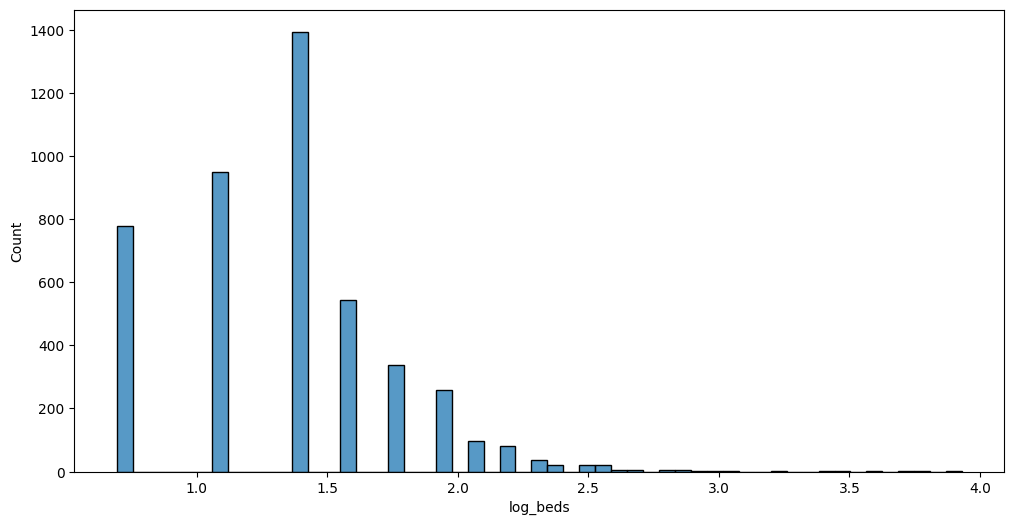

In [845]:
plt.figure(figsize=(12, 6))
sns.histplot(df.log_beds)

In [846]:
df['beds_sqrt'] = np.sqrt(df['beds'])

<Axes: xlabel='beds_sqrt', ylabel='Count'>

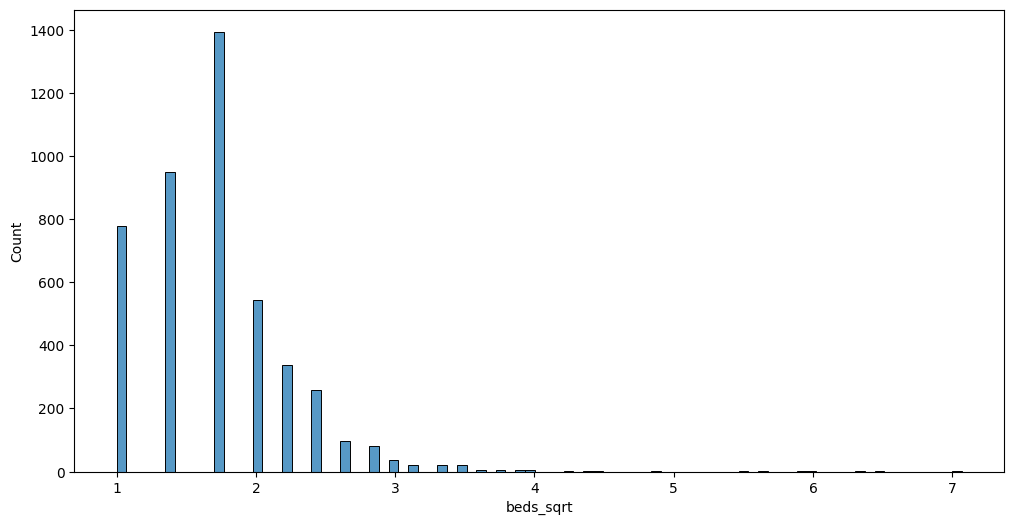

In [847]:
plt.figure(figsize=(12, 6))
sns.histplot(df.beds_sqrt)

In [848]:
df['beds_asinh'] = np.arcsinh(df['beds'])

<Axes: xlabel='beds_asinh', ylabel='Count'>

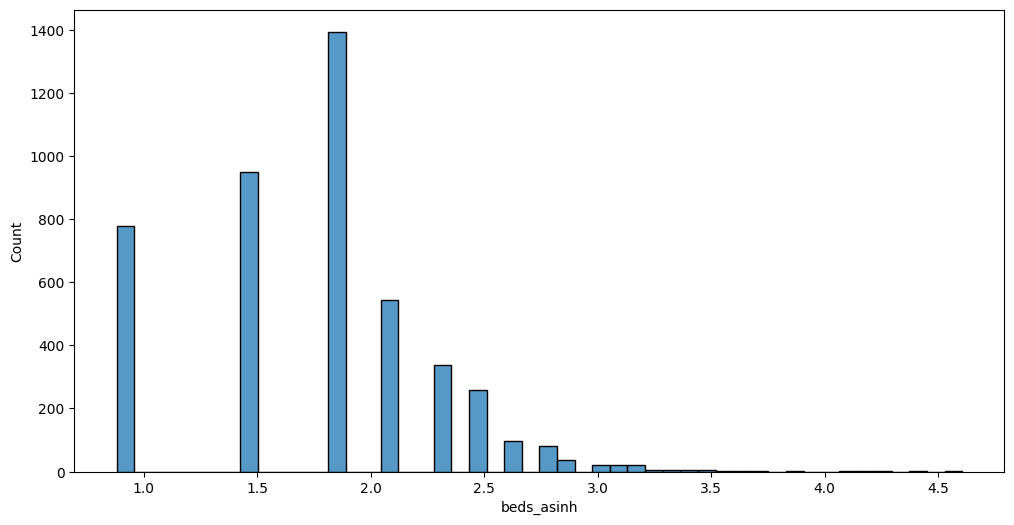

In [849]:
plt.figure(figsize=(12, 6))
sns.histplot(df.beds_asinh)

In [850]:
bins = [0, 1, 2, 3, 4, 5, 6, 10, 20, 50]
labels = ['1', '2', '3', '4', '5', '6', '7-10', '11-20', '20+']
df['beds_binned'] = pd.cut(df['beds'], bins=bins, labels=labels)

<Axes: xlabel='count', ylabel='beds_binned'>

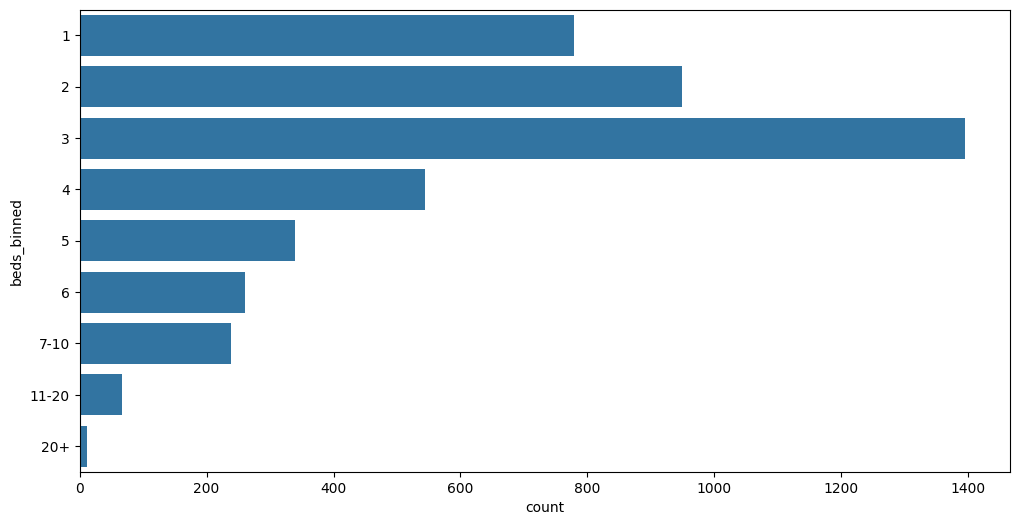

In [851]:
plt.figure(figsize=(12, 6))
sns.countplot(df.beds_binned)

<Axes: xlabel='beds_binned', ylabel='price'>

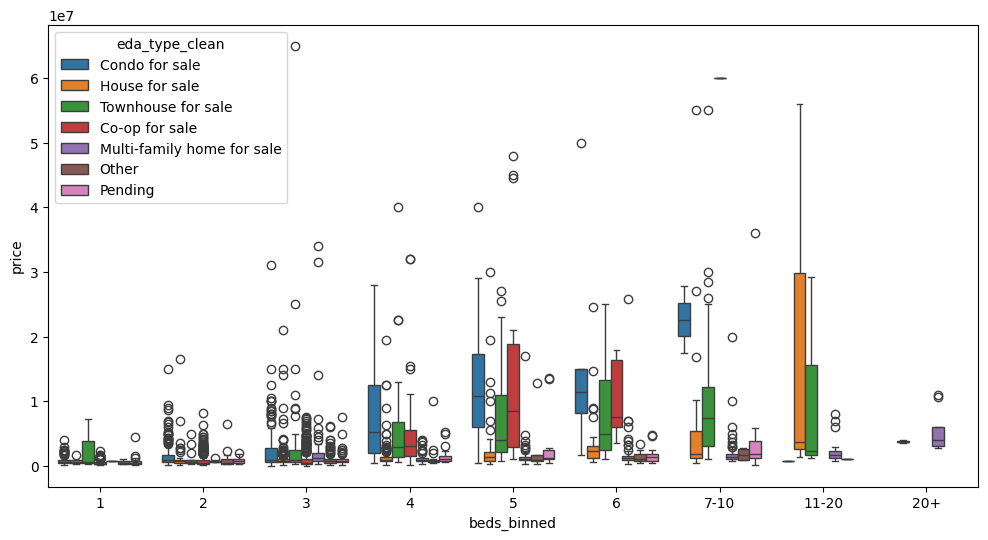

In [852]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='beds_binned', y='price', data=df, order=labels, hue='eda_type_clean')

### Bath

<Axes: xlabel='count', ylabel='bath'>

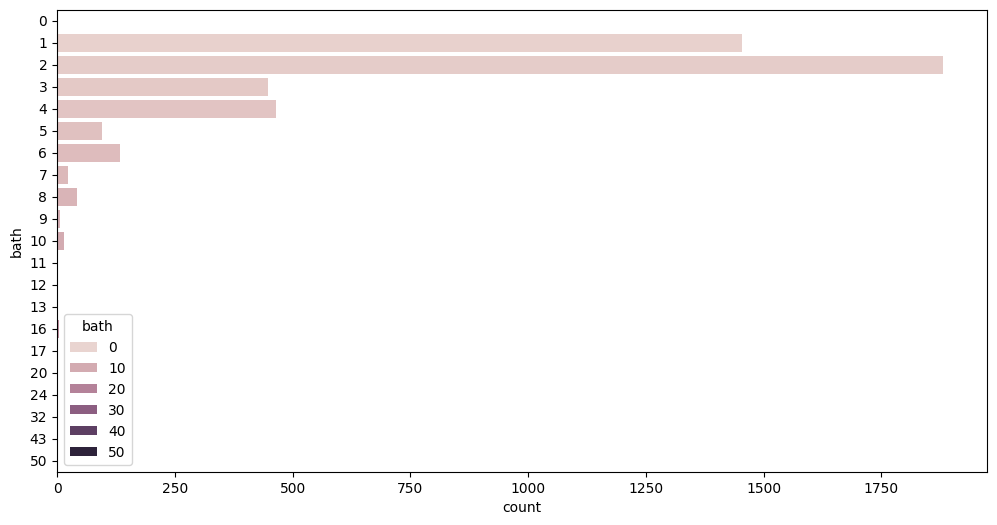

In [853]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='bath', hue='bath')

In [854]:
df.bath.describe()

count    4582.000000
mean        2.352466
std         1.967525
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        50.000000
Name: bath, dtype: float64

Text(0.5, 1.0, 'Price Distribution by Bathroom Count')

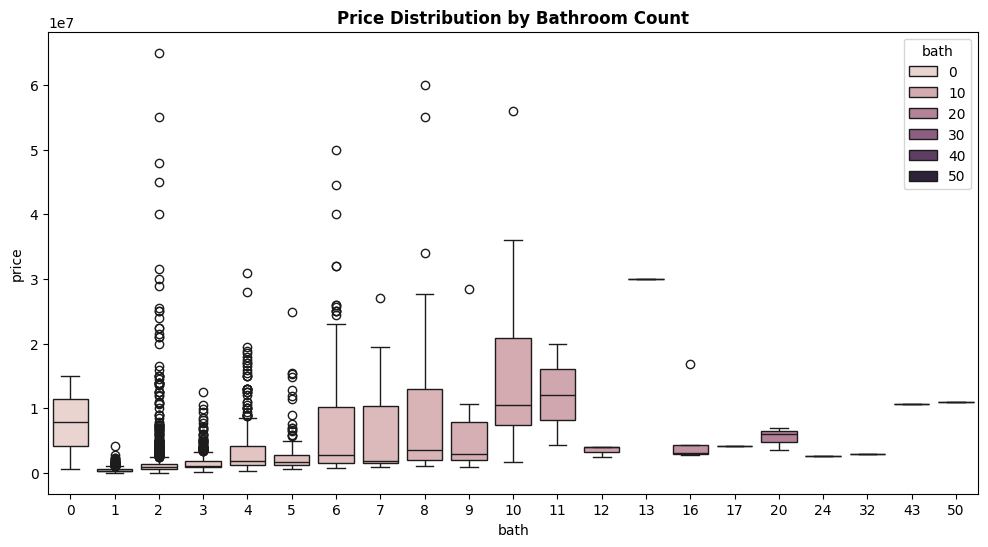

In [855]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,  # Filter outliers
    x='bath',
    y='price',
    showfliers=True,
    hue='bath'
)
#plt.yscale('log')
plt.title('Price Distribution by Bathroom Count', fontweight='bold')

<Axes: ylabel='bath'>

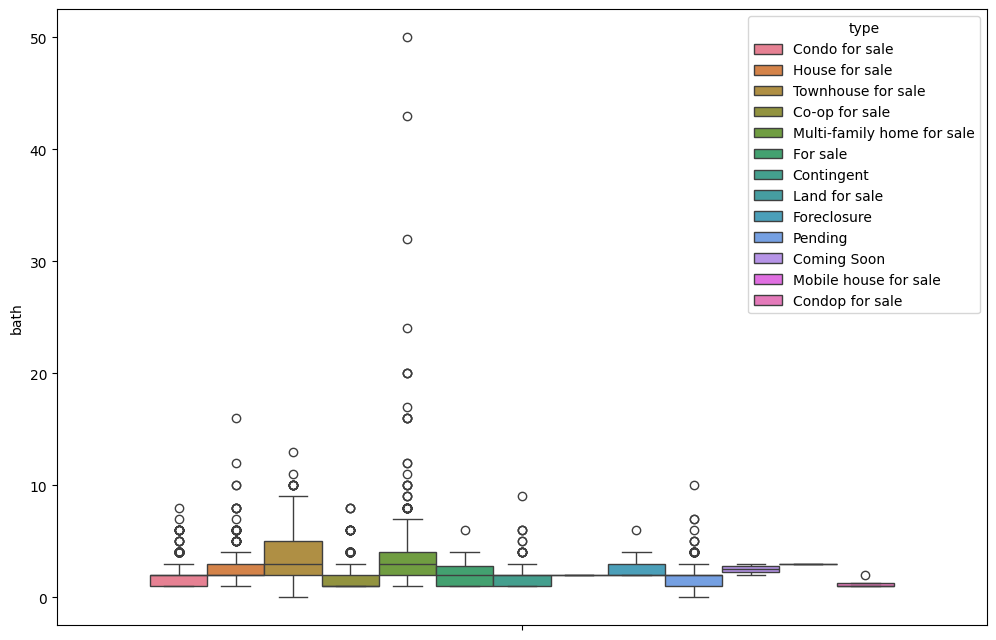

In [856]:
plt.figure(figsize=(12, 8))
sns.boxplot(df,y='bath', hue='type')

<Axes: xlabel='bath', ylabel='log_price'>

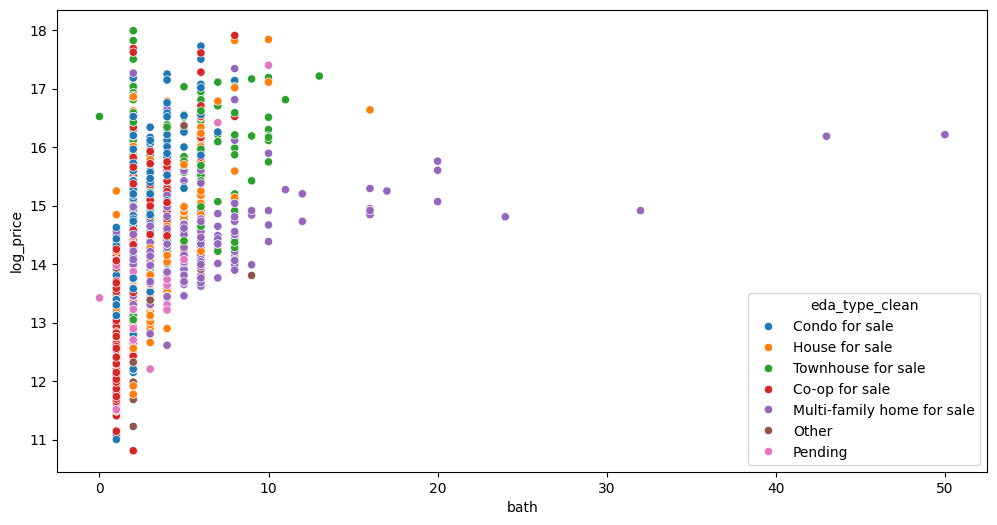

In [857]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='bath', y='log_price', hue='eda_type_clean')

<Axes: xlabel='bath', ylabel='price'>

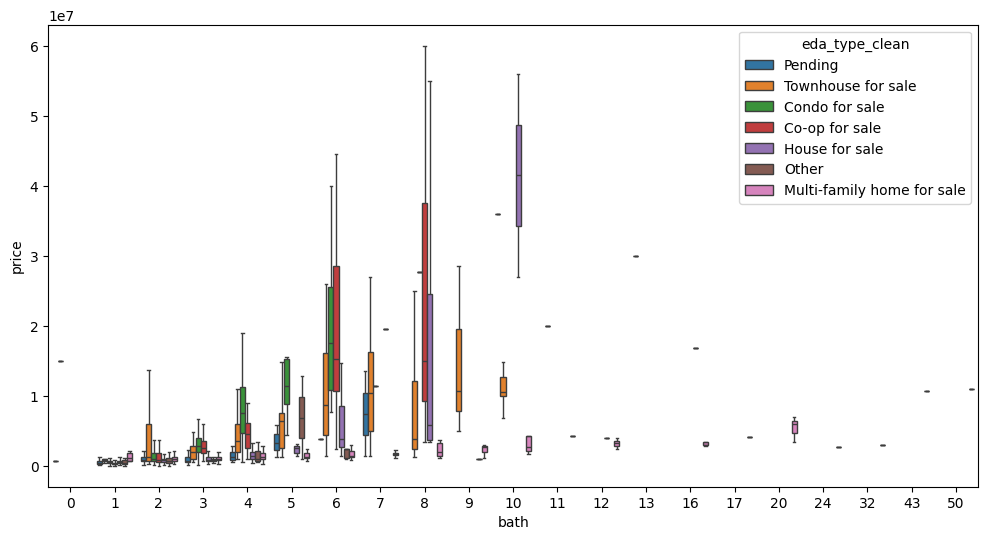

In [858]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='price', hue='eda_type_clean', showfliers=False)

<Axes: xlabel='bath', ylabel='log_price'>

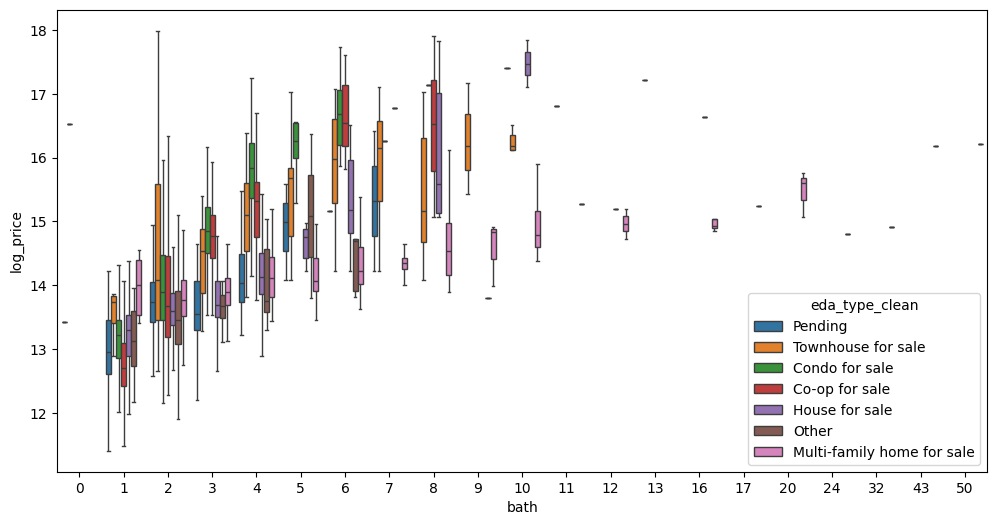

In [859]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='bath', y='log_price', hue='eda_type_clean', showfliers=False)

<Axes: xlabel='bath', ylabel='price'>

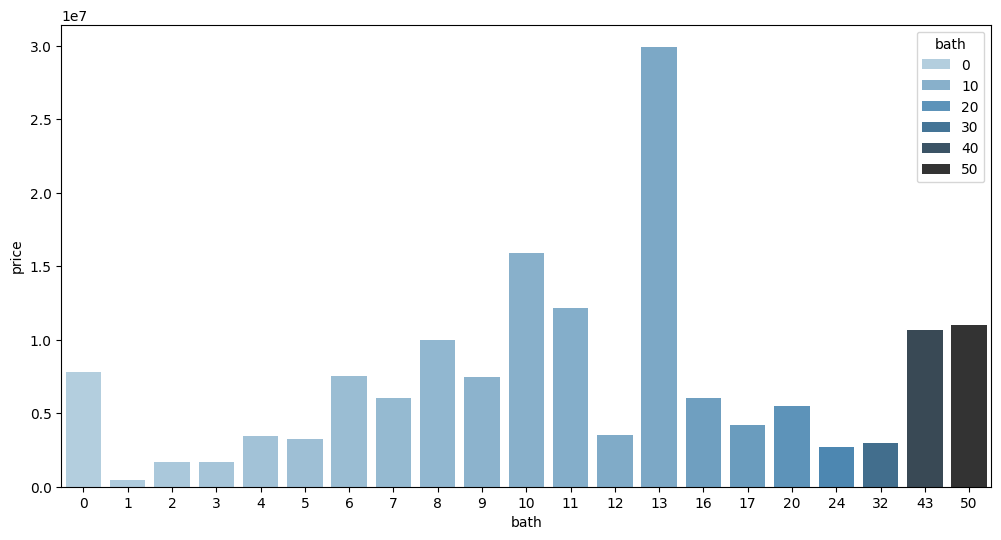

In [860]:
# Mean price dinamic based on number of bathrooms
market_share = (df.groupby('bath')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='bath',
            hue='bath',
            palette='Blues_d')

In [861]:
df['log_bath'] = np.log1p(df.bath)

<Axes: xlabel='log_bath', ylabel='Count'>

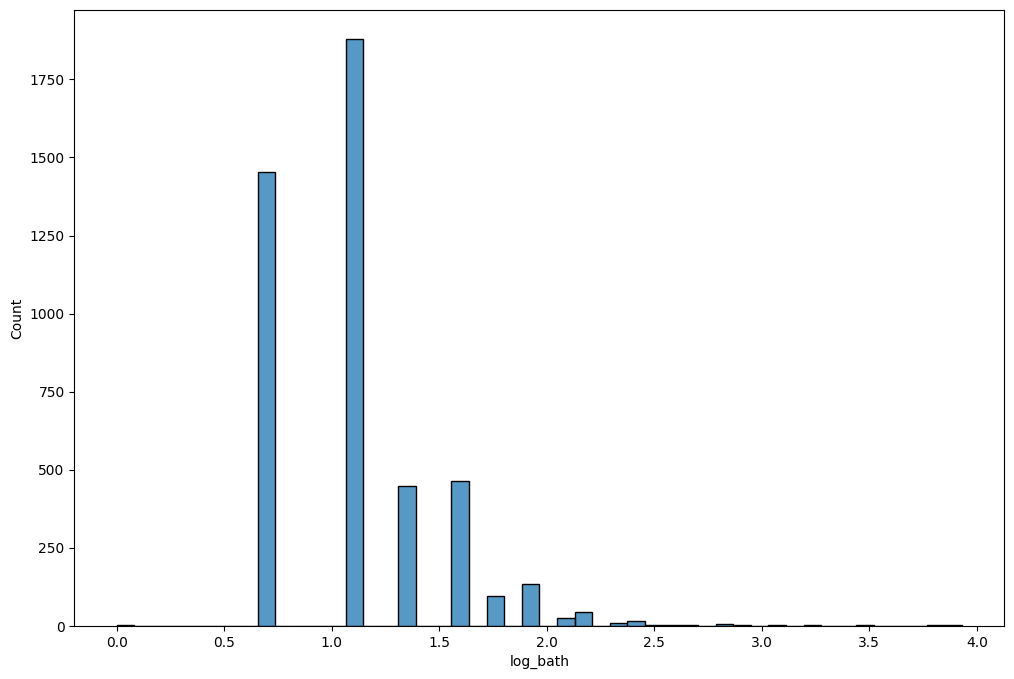

In [862]:
plt.figure(figsize=(12, 8))
sns.histplot(df.log_bath)

In [863]:
bins = [0, 1, 2, 3, 4, 6, 10, 50]
labels = ['1', '2', '3', '4', '5-6', '7-10', '10+']
df['bath_binned'] = pd.cut(df['bath'], bins=bins, labels=labels, include_lowest=True)

<Axes: xlabel='count', ylabel='bath_binned'>

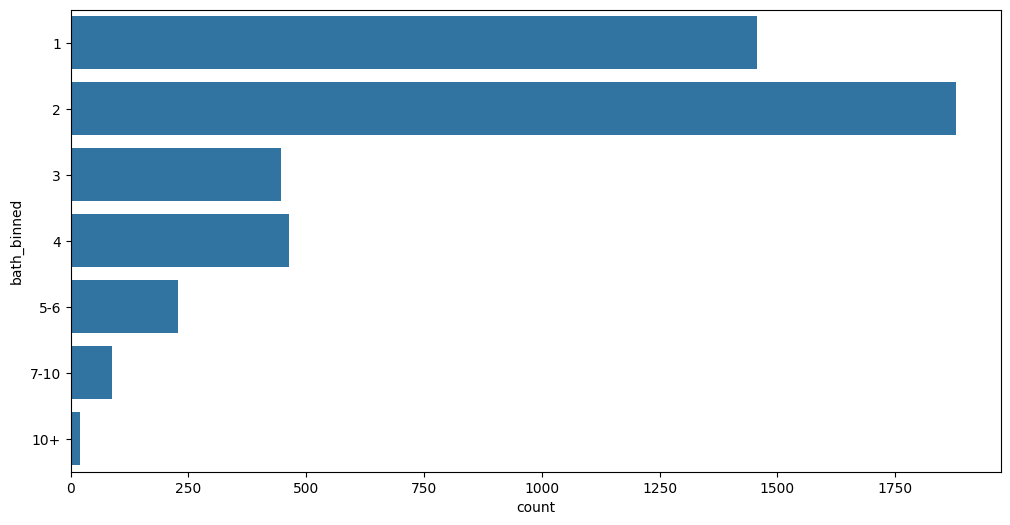

In [864]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='bath_binned')

### *Propertysqft*

<Axes: xlabel='propertysqft', ylabel='Count'>

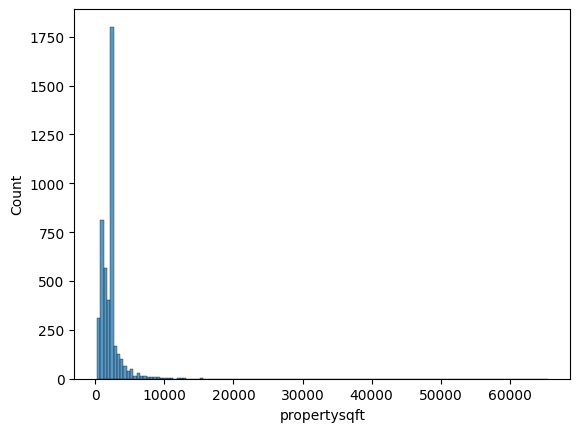

In [865]:
sns.histplot(df.propertysqft)

In [866]:
df.propertysqft.value_counts()

propertysqft
2184.207862     1536
800.000000        54
900.000000        51
750.000000        51
1200.000000       48
                ... 
2002.000000        1
2090.000000        1
886.000000         1
2367.000000        1
12733.000000       1
Name: count, Length: 1444, dtype: int64

In [867]:
df.propertysqft.describe()

count     4582.000000
mean      2172.647158
std       2270.083992
min        230.000000
25%       1200.000000
50%       2184.207862
75%       2184.207862
max      65535.000000
Name: propertysqft, dtype: float64

In [868]:
# The value 2184.207862 appears to have been used as a substitute for missing values.

In [869]:
df[df.propertysqft!=2184.207862].propertysqft.describe()

count     3046.000000
mean      2166.817466
std       2784.361263
min        230.000000
25%        953.500000
50%       1495.500000
75%       2455.000000
max      65535.000000
Name: propertysqft, dtype: float64

In [870]:
# On the dataset without 2184.207862, the median is 1495.50. I’ll impute missing values with this median and mark them with the area_missing flag.

In [871]:
df['area_missing'] = np.where(df['propertysqft'] == 2184.207862, 1, 0)

In [872]:
df['area_missing'].value_counts()

area_missing
0    3046
1    1536
Name: count, dtype: int64

In [873]:
df['propertysqft'] = np.where(df['area_missing'] == 1, 1495.512345, df['propertysqft'])

<Axes: xlabel='price', ylabel='eda_type_clean'>

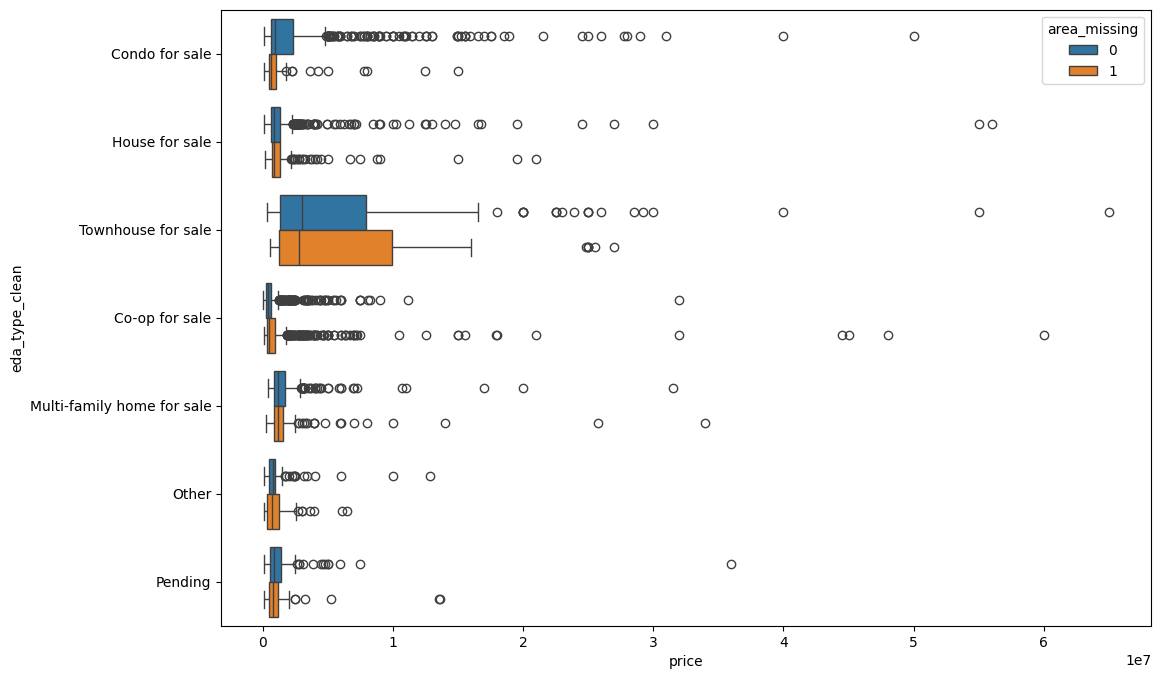

In [874]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, y='eda_type_clean', x='price', hue='area_missing')

In [875]:
# Do not see here significal disproportions

In [876]:
df.propertysqft.describe()

count     4582.000000
mean      1941.779346
std       2292.087025
min        230.000000
25%       1200.000000
50%       1495.512345
75%       1887.750000
max      65535.000000
Name: propertysqft, dtype: float64

<Axes: ylabel='propertysqft'>

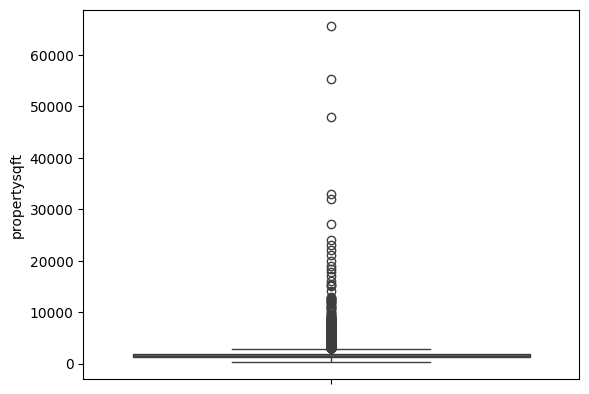

In [877]:
sns.boxplot(df.propertysqft)

<Axes: xlabel='propertysqft', ylabel='Count'>

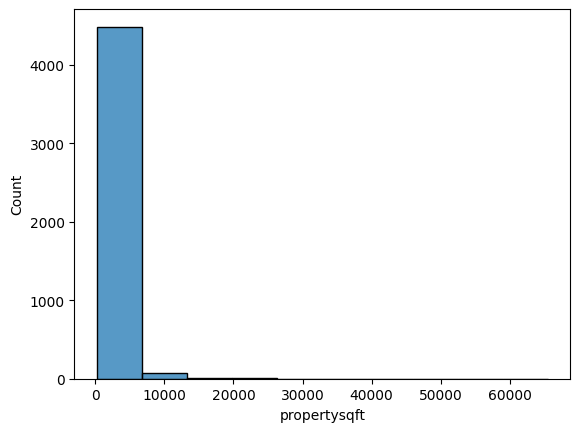

In [878]:
sns.histplot(df.propertysqft, bins=10)

In [879]:
df['propertysqft'].quantile(0.995)

np.float64(12513.660000000058)

In [880]:
# Propertysqft data looks highly skewed. I'll apply log transform to compensate

In [881]:
df['log_area'] = np.log1p(df.propertysqft)

<Axes: xlabel='log_area', ylabel='Count'>

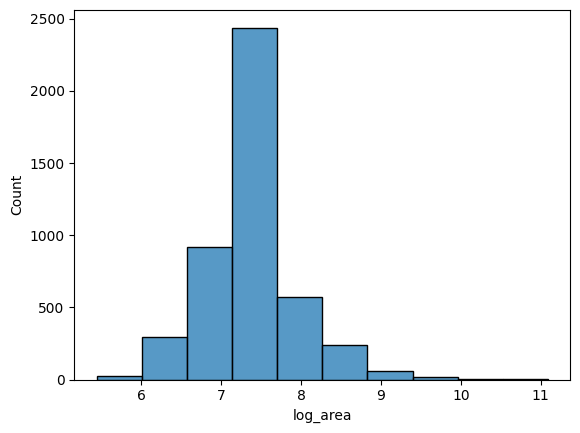

In [882]:
sns.histplot(df.log_area, bins=10)

<Axes: xlabel='log_area', ylabel='log_price'>

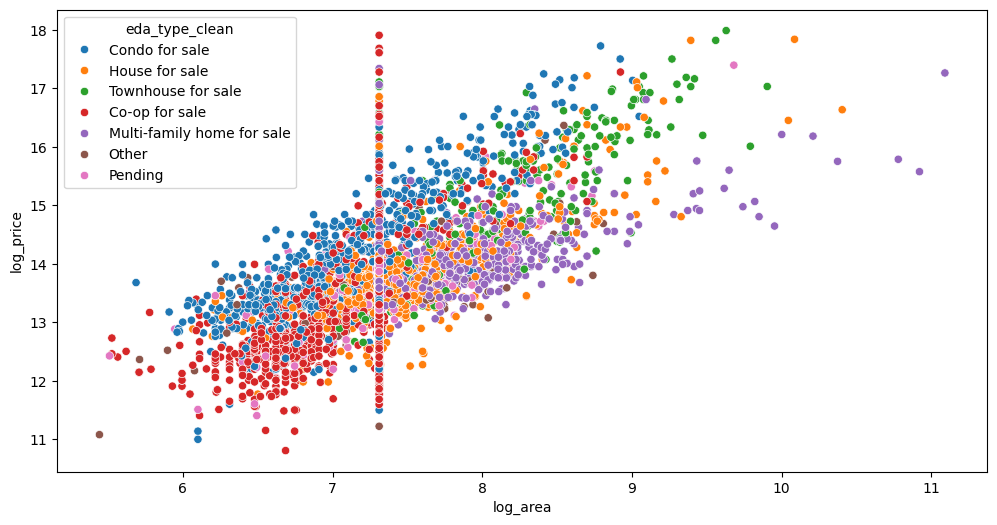

In [883]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='log_area', y='log_price', hue='eda_type_clean')

In [884]:
# In this graph, we can observe data clustering. The vertical line of dots corresponds to the substituted value that was used 
# to fill in missing entries. The most expensive properties across all area ranges are condos.

<Axes: xlabel='count', ylabel='eda_type_clean'>

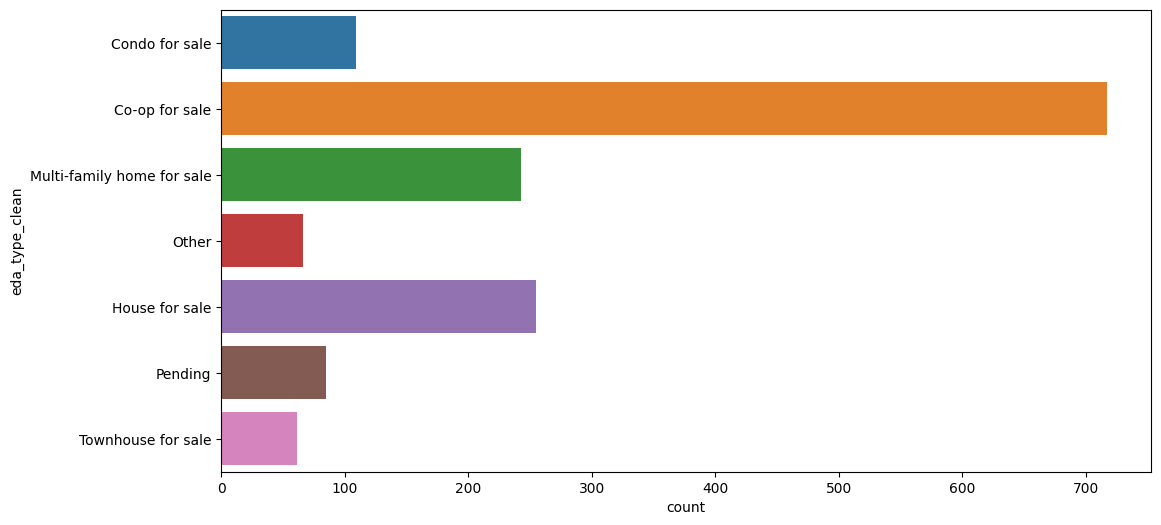

In [885]:
plt.figure(figsize=(12, 6))
sns.countplot(df[df.area_missing==True], y='eda_type_clean', hue='eda_type_clean')

<Axes: xlabel='eda_type_clean', ylabel='price'>

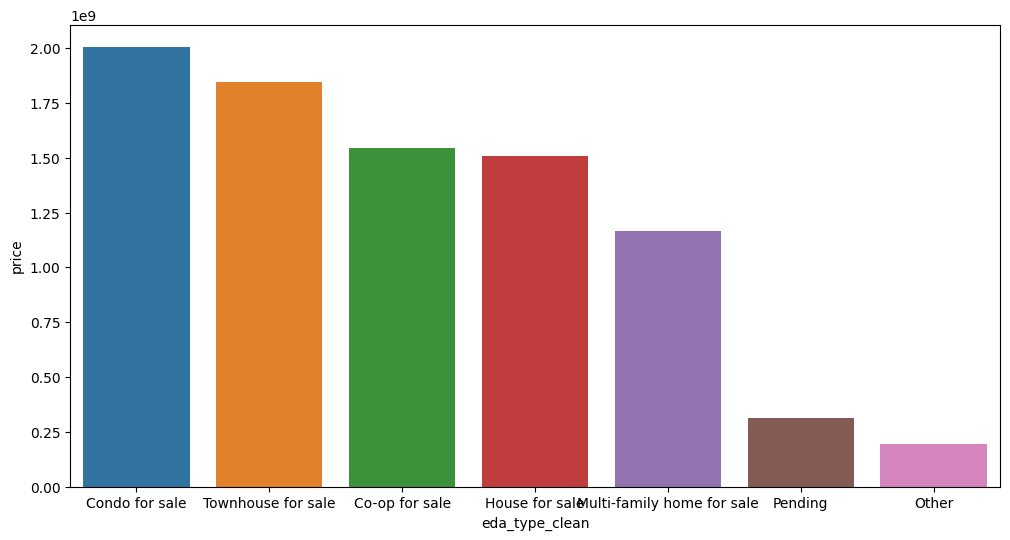

In [886]:
# Mean price dinamic based on type
market_share = (df.groupby('eda_type_clean')['price'].sum()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='eda_type_clean',
            hue='eda_type_clean')

<Axes: xlabel='eda_type_clean', ylabel='price'>

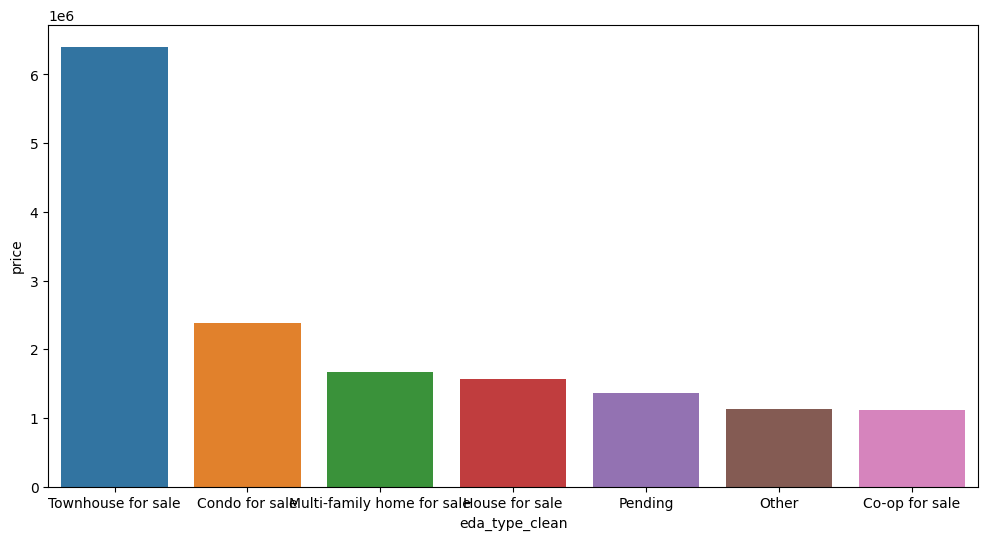

In [887]:
# Mean price dinamic based on type
market_share = (df.groupby('eda_type_clean')['price'].mean()).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            y='price',
            x='eda_type_clean',
            hue='eda_type_clean')

In [888]:
# Most properites with missed values are co-op, and that item has the least mean price. So those missing properties shouldn't
# distort upper market.

### All address data

In [889]:
address_columns = ['address', 'state',
       'main_address', 'administrative_area_level_2', 'locality',
       'sublocality', 'street_name', 'long_name', 'formatted_address']

In [890]:
df[address_columns].head(7)

,address,state,main_address,administrative_area_level_2,locality,sublocality,street_name,long_name,formatted_address
0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N..."
1,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA"
2,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA"
3,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA"
4,584 Park Pl,"Brooklyn, NY 11238","584 Park PlBrooklyn, NY 11238",United States,New York,Kings County,Brooklyn,Park Place,"584 Park Pl, Brooklyn, NY 11238, USA"
5,157 W 126th St Unit 1B,"New York, NY 10027","157 W 126th St Unit 1BNew York, NY 10027",New York,New York County,New York,Manhattan,157,"157 W 126th St #1b, New York, NY 10027, USA"
6,177 Benedict Rd,"Staten Island, NY 10304","177 Benedict RdStaten Island, NY 10304",United States,New York,Richmond County,Staten Island,Benedict Road,"177 Benedict Rd, Staten Island, NY 10304, USA"


In [891]:
# Address and formatted address probably should be dropped.

In [892]:
# State contain zip. Could be usefull

In [893]:
df['zip'] = df['state'].str[-5:]

# Filter invalid ZIPs (e.g., non-numeric)
df['zip'] = df['zip'].where(df['zip'].str.isdigit())

In [894]:
df.zip.isna().sum()

np.int64(0)

In [895]:
df.zip.value_counts()

zip
11375    102
11235    100
11209     91
11234     89
10314     81
        ... 
11040      1
11364      1
10455      1
10282      1
11416      1
Name: count, Length: 178, dtype: int64

In [896]:
df.state.value_counts()

state
Brooklyn, NY 11235            99
Brooklyn, NY 11209            91
Forest Hills, NY 11375        88
Brooklyn, NY 11234            86
Staten Island, NY 10314       80
                              ..
Ditmas Park, NY 11226          1
Jackson Heights, NY 11370      1
New York, NY 10282             1
Long Island City, NY 11106     1
Ozone Park, NY 11416           1
Name: count, Length: 307, dtype: int64

In [897]:
df.administrative_area_level_2.value_counts()

administrative_area_level_2
United States      2372
New York           2135
New York County      21
11214                 8
Kings County          6
Queens County         6
Bronx County          4
11229                 3
10003                 2
10017                 2
10310                 2
10471                 2
10306                 2
10002                 2
11414                 1
11417                 1
11234                 1
10309                 1
10301                 1
10303                 1
10463                 1
10304                 1
10312                 1
10465                 1
11412                 1
Brooklyn              1
10466                 1
11237                 1
11218                 1
Name: count, dtype: int64

In [898]:
# Messy feature, better should use borough

In [899]:
#locality	sublocality	street_name	long_name

In [900]:
df.locality.value_counts()

locality
New York           2393
New York County     928
Queens County       536
Kings County        441
Bronx County        172
Richmond County      58
United States        37
Queens                6
Brooklyn              6
The Bronx             4
Flatbush              1
Name: count, dtype: int64

In [901]:
df.sublocality.value_counts()

sublocality
New York            965
Kings County        696
Queens County       655
Queens              534
Richmond County     460
Brooklyn            441
Bronx County        291
New York County     270
The Bronx           174
Staten Island        58
Manhattan            21
Flushing              4
Coney Island          3
Riverdale             3
East Bronx            1
Jackson Heights       1
Brooklyn Heights      1
Rego Park             1
Fort Hamilton         1
Dumbo                 1
Snyder Avenue         1
Name: count, dtype: int64

In [902]:
df.street_name.value_counts()

street_name
Manhattan          928
Brooklyn           696
Queens             655
Staten Island      460
The Bronx          294
                  ... 
2501                 1
67th Drive           1
Todt Hill            1
Saunders Street      1
Mount Eden           1
Name: count, Length: 174, dtype: int64

In [903]:
df.long_name.value_counts()

long_name
2                   19
200                 18
100                 18
50                  15
40                  14
                    ..
65th Road            1
7666                 1
Kenmore Court        1
Corbin Avenue        1
West 87th Street     1
Name: count, Length: 2729, dtype: int64

In [904]:
address_columns_to_drop = ['address',
 'state',
 'main_address',
 'administrative_area_level_2',
 'locality',
 'sublocality',
 'street_name',
 'long_name']

In [905]:
df = df.drop(columns=address_columns_to_drop)

In [906]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [907]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'formatted_address', 'latitude', 'longitude', 'log_price',
       'price_segment', 'eda_type_clean', 'log_beds', 'beds_sqrt',
       'beds_asinh', 'beds_binned', 'log_bath', 'bath_binned', 'area_missing',
       'log_area', 'zip'],
      dtype='object')

### Add boroughs

In [908]:
boroughs_file = '../data/raw/nyc_boroughs.geojson'

In [909]:
gdf_boroughs = gpd.read_file(boroughs_file)

<Axes: >

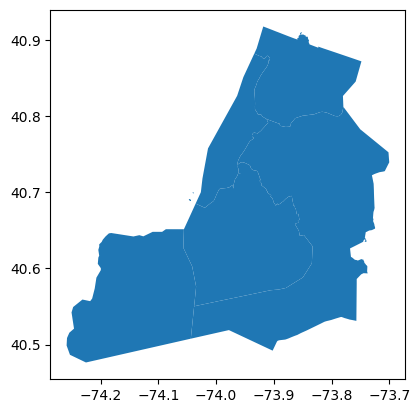

In [910]:
gdf_boroughs.plot()

In [911]:
gdf_boroughs

,name,geometry
0,The Bronx,"MULTIPOLYGON (((-73.93263 40.81897, -73.93274 ..."
1,Brooklyn,"MULTIPOLYGON (((-73.99426 40.70403, -73.99341 ..."
2,Queens,"MULTIPOLYGON (((-73.76604 40.7984, -73.75637 4..."
3,Manhattan,"MULTIPOLYGON (((-74.03993 40.69859, -74.04008 ..."
4,Staten Island,"MULTIPOLYGON (((-74.03805 40.55034, -74.03634 ..."


In [912]:
gdf_boroughs_utm = gdf_boroughs.to_crs("EPSG:32618")

In [913]:
gdf_houses = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs=gdf_boroughs.crs
)

In [914]:
df_with_borough = gpd.sjoin(
    gdf_houses,
    gdf_boroughs[['name', 'geometry']],  # Only keep needed columns
    how='left',
    predicate='within'
)

In [915]:
df_with_borough

,brokertitle,type,price,beds,bath,propertysqft,formatted_address,latitude,longitude,log_price,...,beds_asinh,beds_binned,log_bath,bath_binned,area_missing,log_area,zip,geometry,index_right,name
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2,1400.000000,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483,12.660328,...,1.443635,2,1.098612,2,0,7.244942,10022,POINT (-73.97448 40.76126),3,Manhattan
1,Brokered by Sowae Corp,House for sale,260000,4,2,2015.000000,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109,12.468437,...,2.094713,4,1.098612,2,0,7.608871,10312,POINT (-74.19611 40.54181),4,Staten Island
2,Brokered by COMPASS,Condo for sale,69000,3,1,445.000000,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613,11.141862,...,1.818446,3,0.693147,1,0,6.100319,10022,POINT (-73.97461 40.7614),3,Manhattan
3,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2,14175.000000,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856,17.822844,...,2.644121,7-10,1.098612,2,0,9.559306,10065,POINT (-73.96986 40.76722),3,Manhattan
4,Brokered by Sowae Corp,House for sale,690000,5,2,4004.000000,"584 Park Pl, Brooklyn, NY 11238, USA",40.674363,-73.958725,13.444447,...,2.312438,5,1.098612,2,0,8.295299,11238,POINT (-73.95872 40.67436),1,Brooklyn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4577,Brokered by COMPASS,Co-op for sale,599000,1,1,1495.512345,"222 E 80th St #3a, New York, NY 10075, USA",40.774350,-73.955879,13.303017,...,0.881374,1,0.693147,1,1,7.310893,10075,POINT (-73.95588 40.77435),3,Manhattan
4578,Brokered by Mjr Real Estate Llc,Co-op for sale,245000,1,1,1495.512345,"97-40 62nd Dr, Rego Park, NY 11374, USA",40.732538,-73.860152,12.409013,...,0.881374,1,0.693147,1,1,7.310893,11374,POINT (-73.86015 40.73254),2,Queens
4579,Brokered by Douglas Elliman - 575 Madison Ave,Co-op for sale,1275000,1,1,1495.512345,"427 W 21st St, New York, NY 10011, USA",40.745882,-74.003398,14.058457,...,0.881374,1,0.693147,1,1,7.310893,10011,POINT (-74.0034 40.74588),3,Manhattan
4580,Brokered by E Realty International Corp,Condo for sale,598125,2,1,655.000000,"91-23 Corona Ave. #4b, Flushing, NY 11373, USA",40.742770,-73.872752,13.301555,...,1.443635,2,0.693147,1,0,6.486161,11373,POINT (-73.87275 40.74277),2,Queens


In [916]:
df['borough'] = df_with_borough['name']

In [917]:
df['borough'].isna().sum()

np.int64(0)

In [918]:
# Nothing missing

<Axes: xlabel='longitude', ylabel='latitude'>

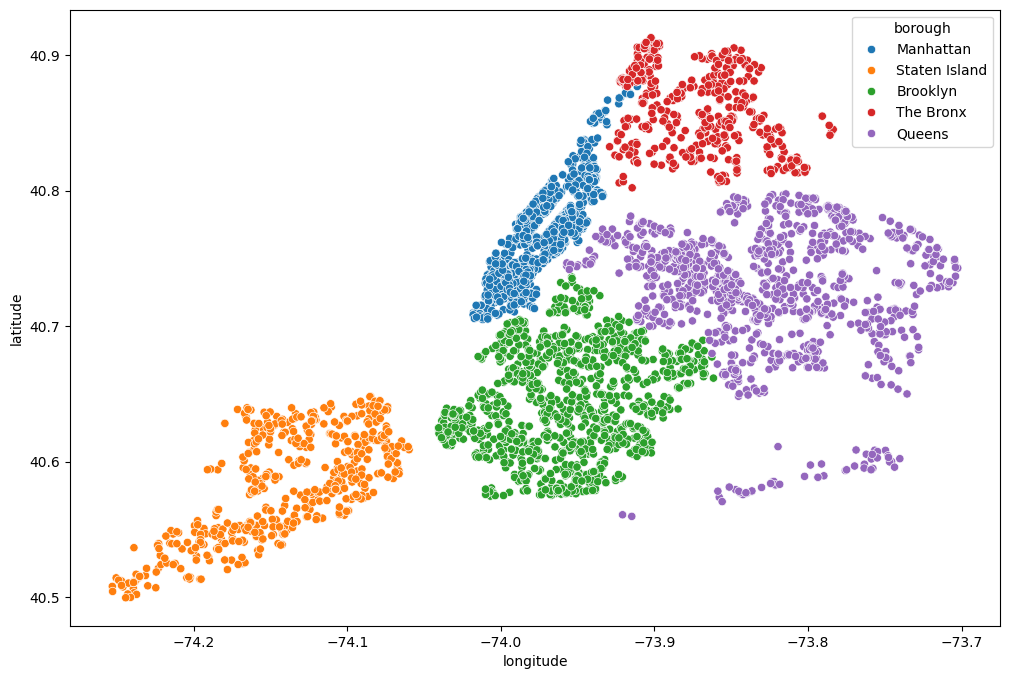

In [919]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x="longitude", y="latitude", hue="borough", data=df)

In [920]:
# Looks great!

<Axes: xlabel='price', ylabel='borough'>

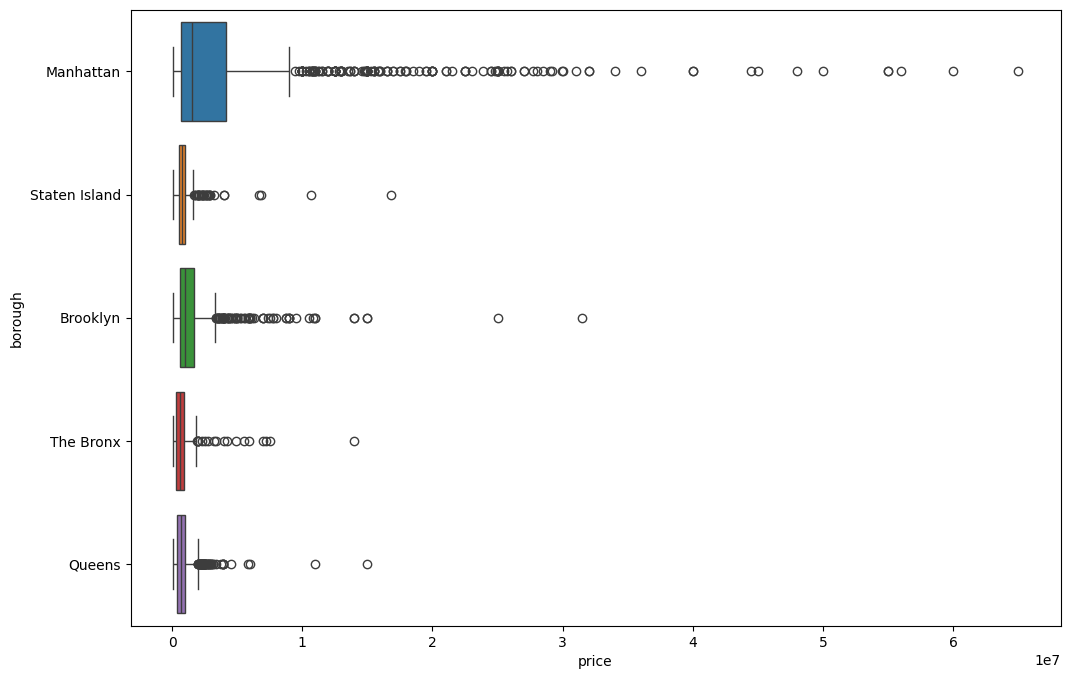

In [921]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='price', y='borough', hue='borough')

<Axes: xlabel='log_price', ylabel='borough'>

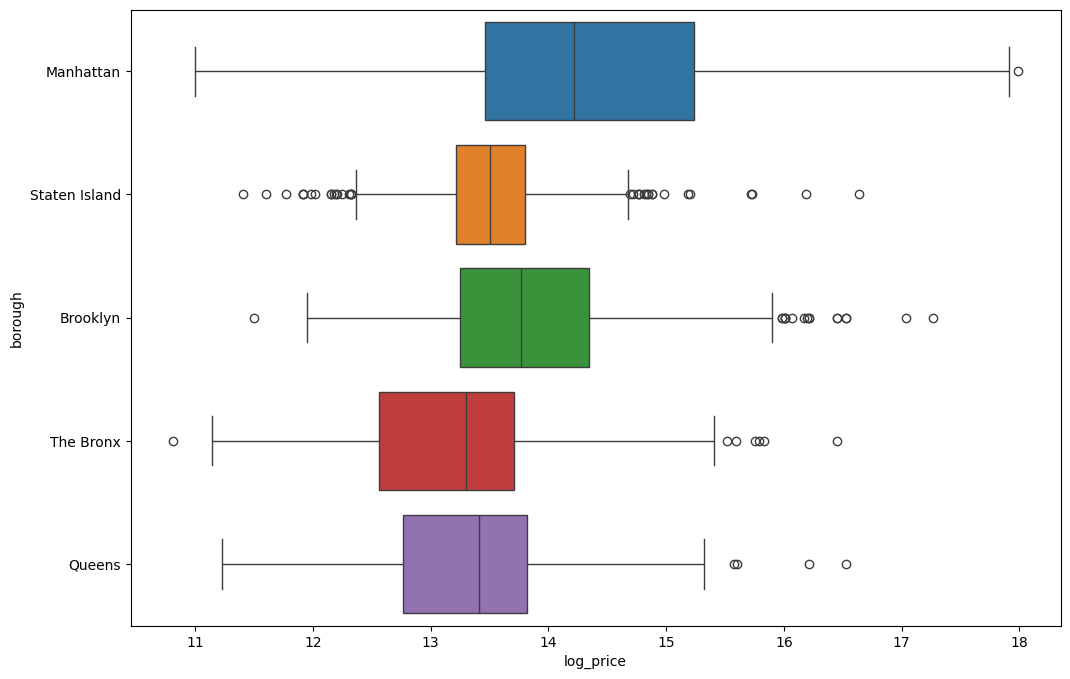

In [922]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='log_price', y='borough', hue='borough')

In [923]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'formatted_address', 'latitude', 'longitude', 'log_price',
       'price_segment', 'eda_type_clean', 'log_beds', 'beds_sqrt',
       'beds_asinh', 'beds_binned', 'log_bath', 'bath_binned', 'area_missing',
       'log_area', 'zip', 'borough'],
      dtype='object')

<Axes: xlabel='beds', ylabel='borough'>

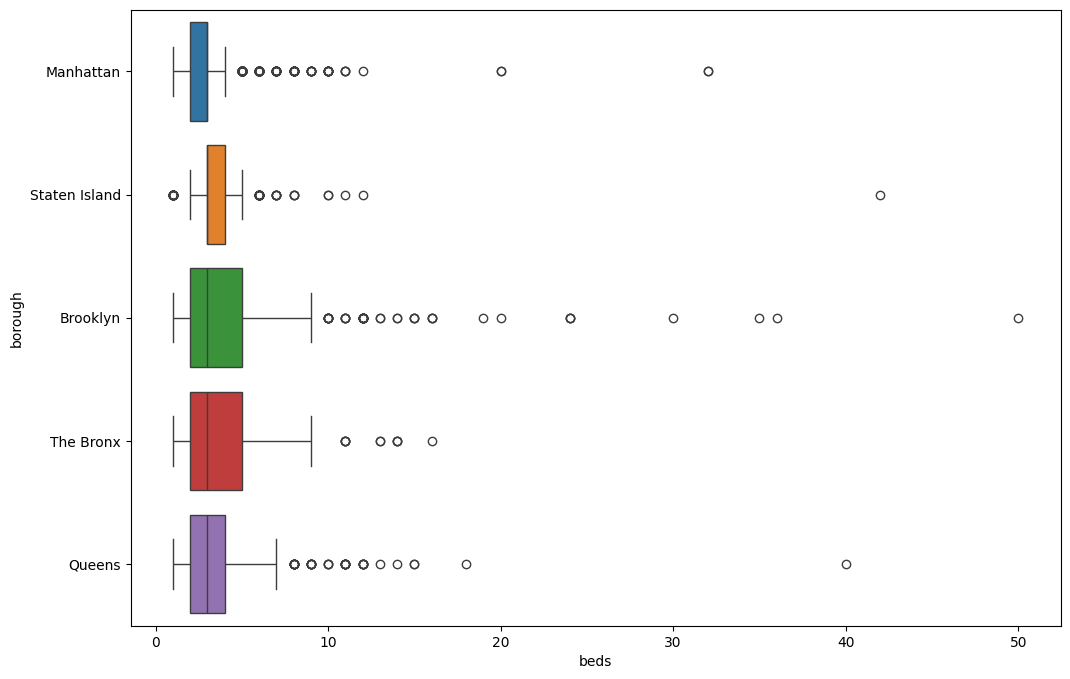

In [924]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='beds', y='borough', hue='borough')

<Axes: xlabel='beds_binned', ylabel='price'>

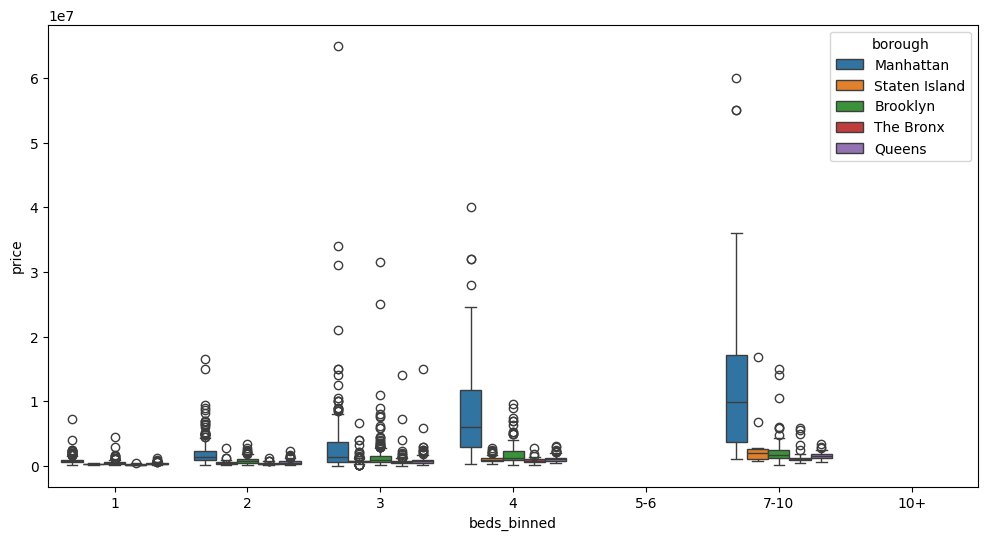

In [925]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='beds_binned', y='price', data=df, order=labels, hue='borough')

<Axes: xlabel='bath', ylabel='borough'>

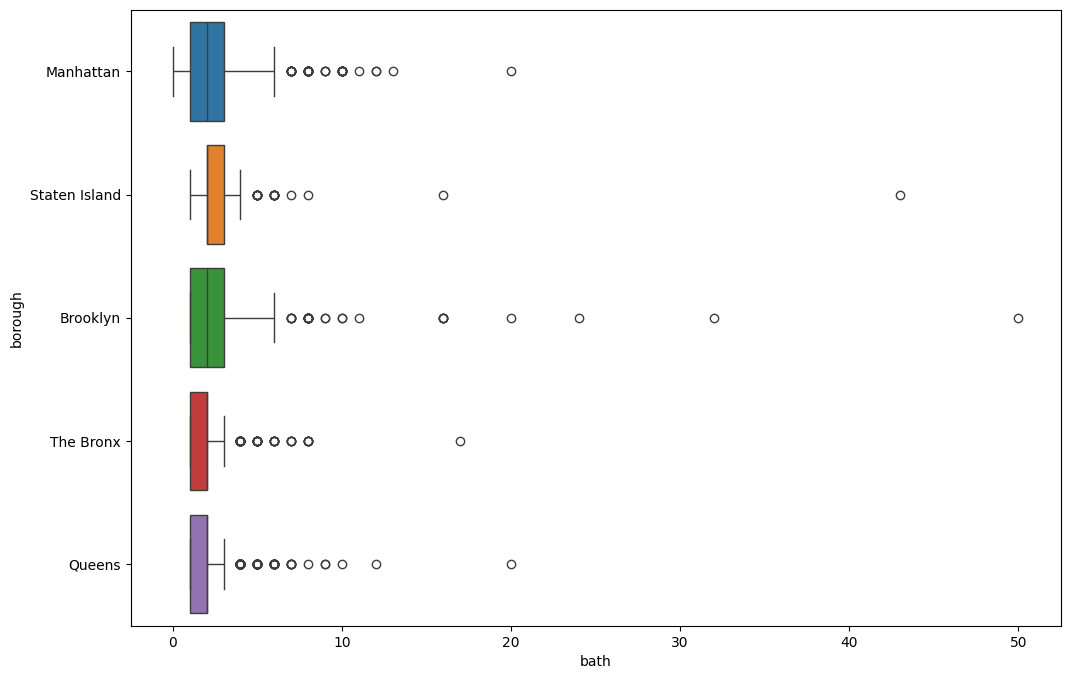

In [926]:
plt.figure(figsize=(12, 8))
sns.boxplot(df, x='bath', y='borough', hue='borough')

<Axes: xlabel='borough', ylabel='count'>

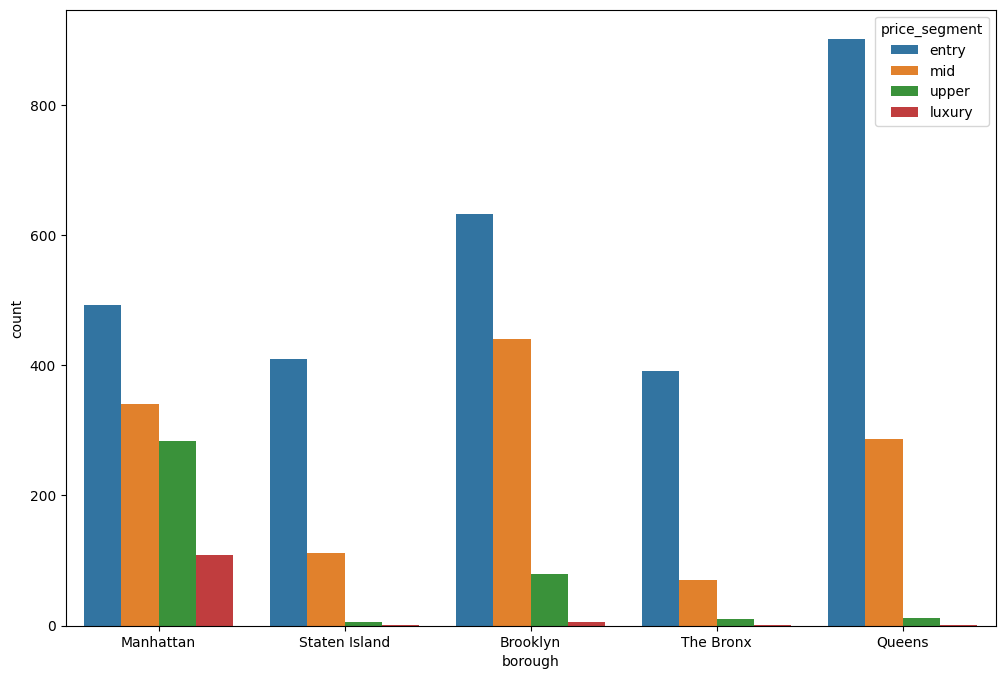

In [927]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='borough', hue='price_segment')

<Axes: xlabel='borough', ylabel='price'>

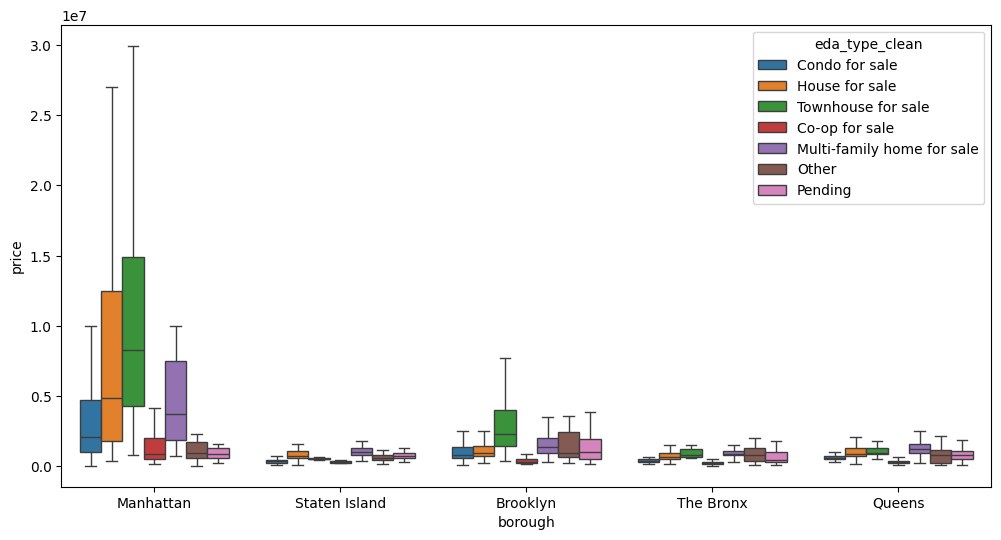

In [928]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='borough', y='price', hue='eda_type_clean', showfliers=False)

<Axes: xlabel='count', ylabel='borough'>

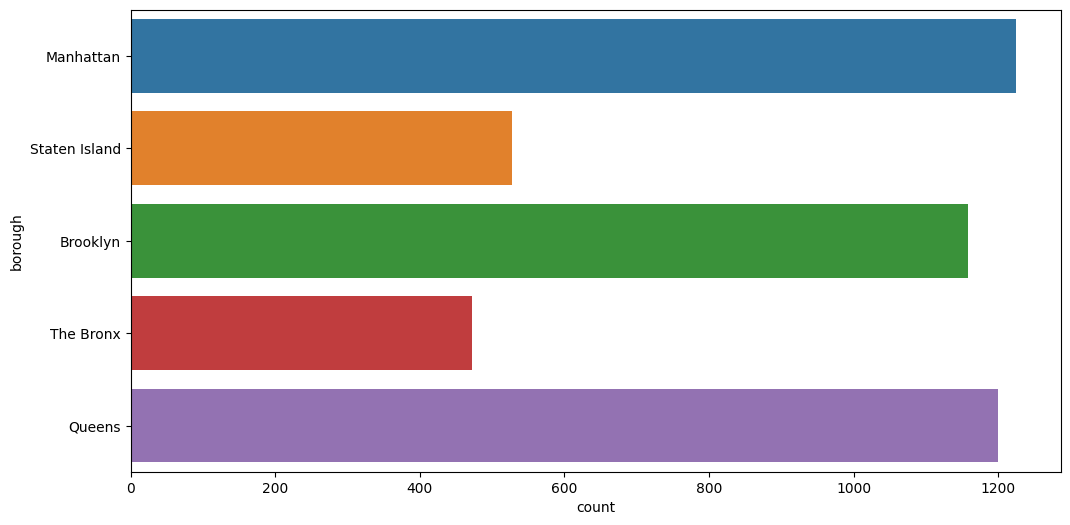

In [929]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='borough', hue='borough')

<Axes: xlabel='price', ylabel='borough'>

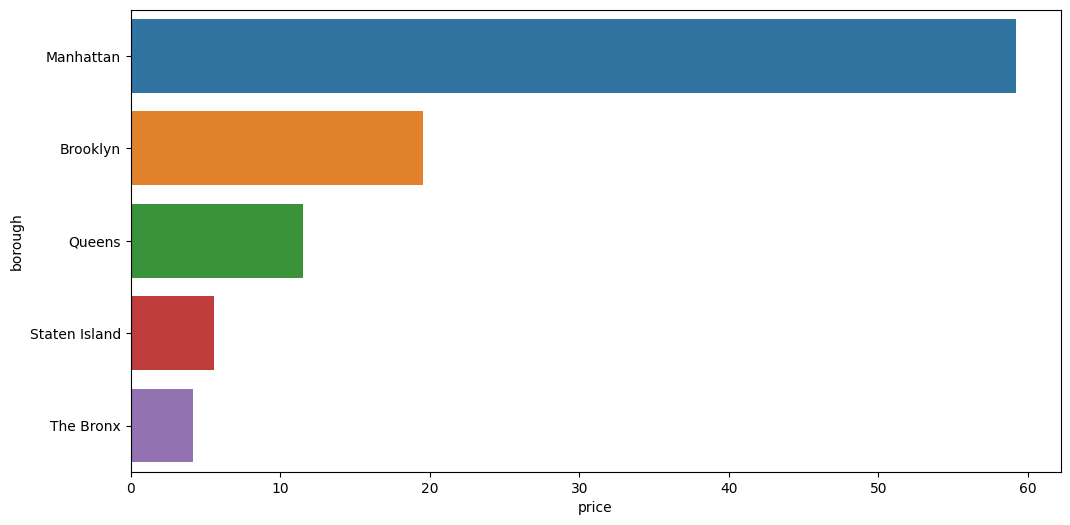

In [930]:
# Calculate market share by types
market_share = (df.groupby('borough')['price'].sum() / df.price.sum() * 100).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
market_share_df = market_share.reset_index()
sns.barplot(data=market_share_df,
            x='price',
            y='borough',
           hue='borough')

In [931]:
# Ok, those plots confirm what we already know, all the money is in Manhattan.

In [932]:
df.borough.value_counts()

borough
Manhattan        1225
Queens           1200
Brooklyn         1158
Staten Island     527
The Bronx         472
Name: count, dtype: int64

In [933]:
# Enconding for boroughs. Only top boroughs
borough_dummies = pd.get_dummies(df['borough'], prefix='borough')

top_boroughs = ['borough_Manhattan', 'borough_Brooklyn', 'borough_Queens']
df = pd.concat([df, borough_dummies[top_boroughs]], axis=1)

In [934]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'formatted_address', 'latitude', 'longitude', 'log_price',
       'price_segment', 'eda_type_clean', 'log_beds', 'beds_sqrt',
       'beds_asinh', 'beds_binned', 'log_bath', 'bath_binned', 'area_missing',
       'log_area', 'zip', 'borough', 'borough_Manhattan', 'borough_Brooklyn',
       'borough_Queens'],
      dtype='object')

In [935]:
print(np.log(60_000_000))
print(np.log(30_000_000))
print(np.log(10_000_000))
print(np.log(2_000_000))
print(np.log(1_000_000))
print(np.log(500_000))

17.909855120186375
17.216707939626428
16.11809565095832
14.508657738524219
13.815510557964274
13.122363377404328


In [936]:
### Add price_per_sqft

In [937]:
df['price_per_sqft'] = df.price/df.propertysqft

In [938]:
df['log_pps'] = np.log1p(df.price_per_sqft)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

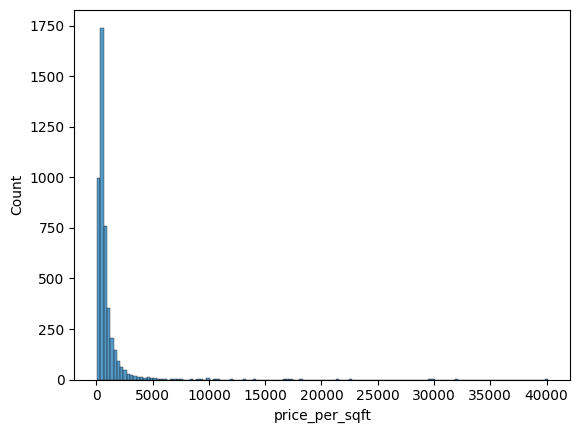

In [939]:
sns.histplot(df, x='price_per_sqft')

<Axes: xlabel='price_per_sqft', ylabel='eda_type_clean'>

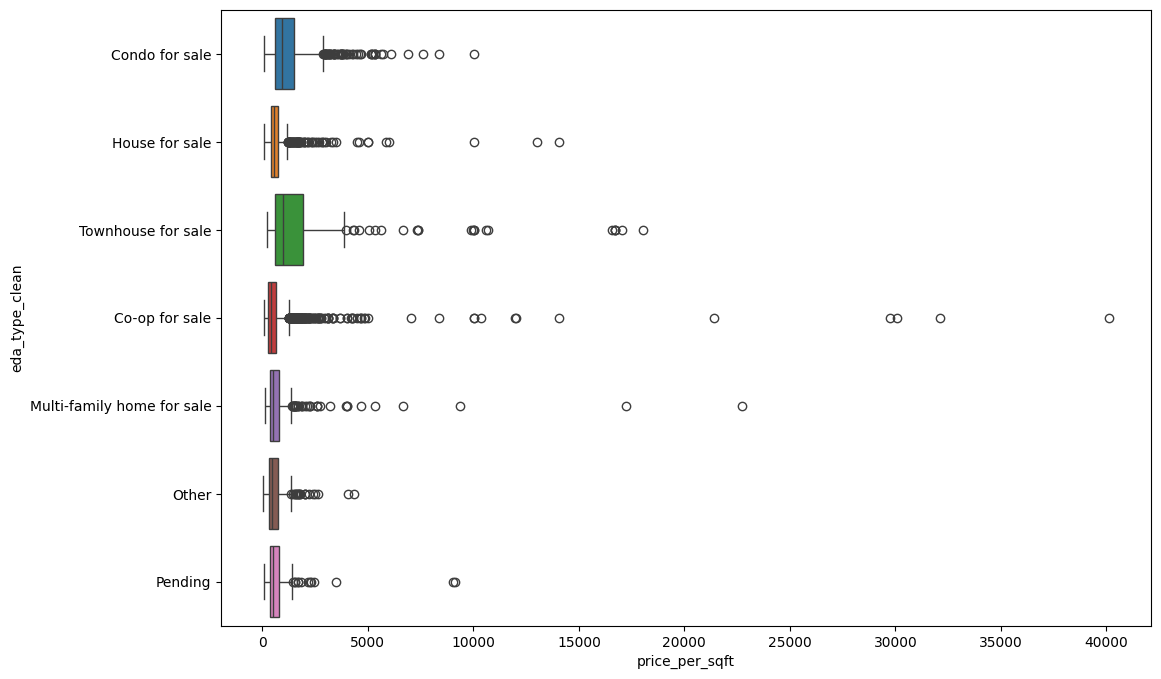

In [940]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='eda_type_clean', hue='eda_type_clean')

In [941]:
df[['price_per_sqft', 'price']].corr()

,price_per_sqft,price
price_per_sqft,1.000000,0.719888
price,0.719888,1.000000


<Axes: xlabel='price_per_sqft', ylabel='borough'>

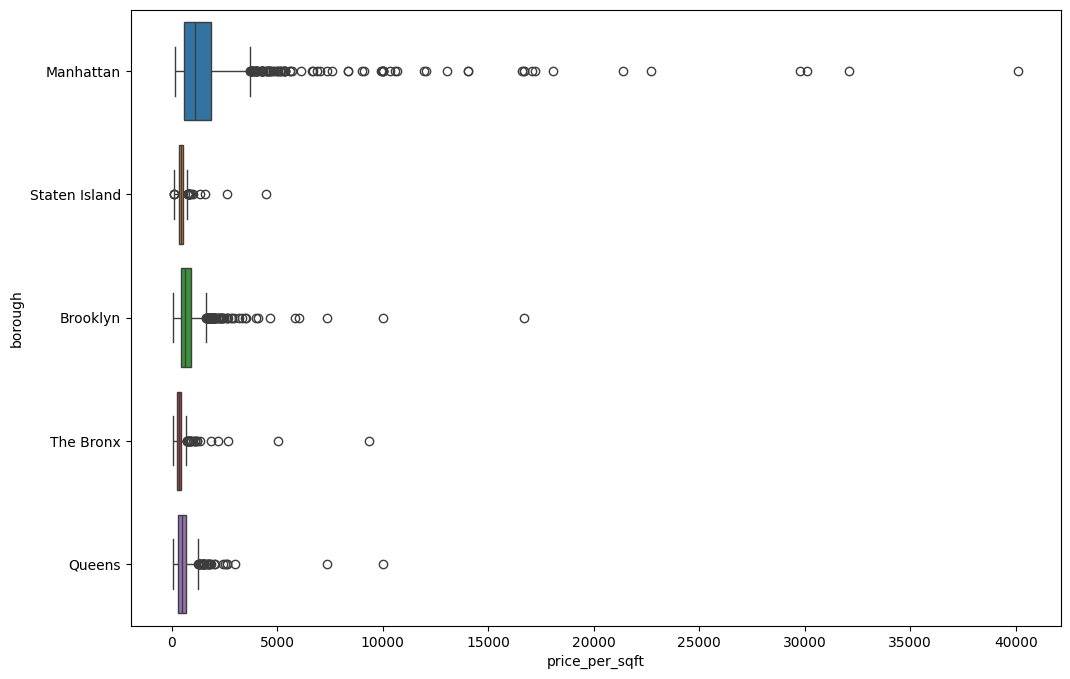

In [942]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='borough')

<Axes: xlabel='price_per_sqft', ylabel='borough'>

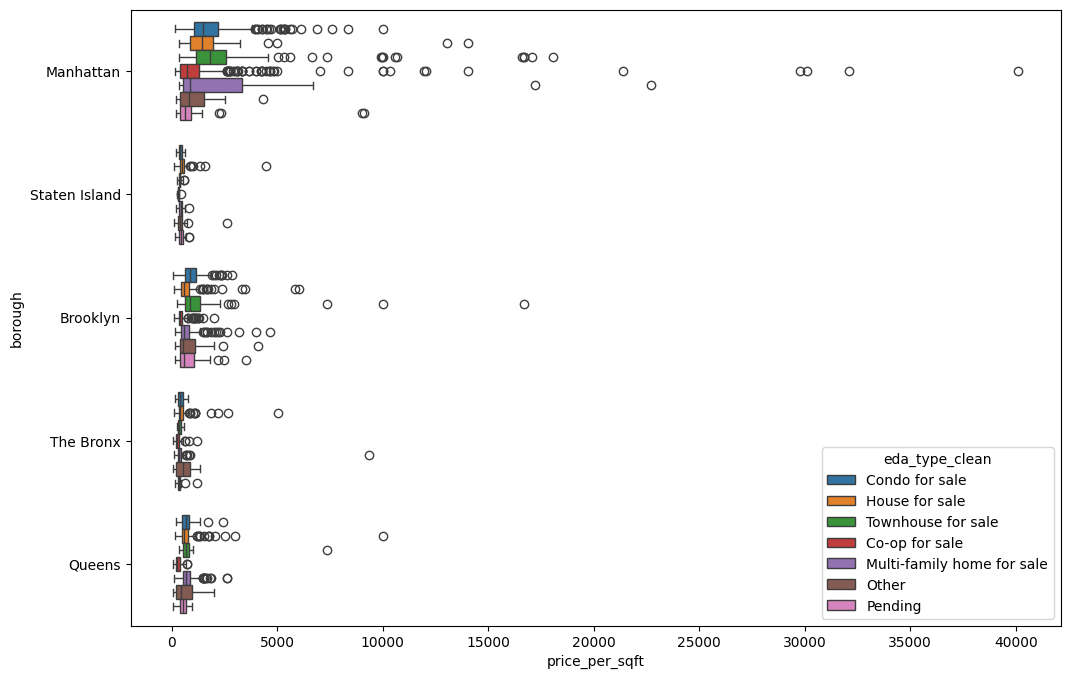

In [943]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='eda_type_clean')

<Axes: xlabel='price_per_sqft', ylabel='borough'>

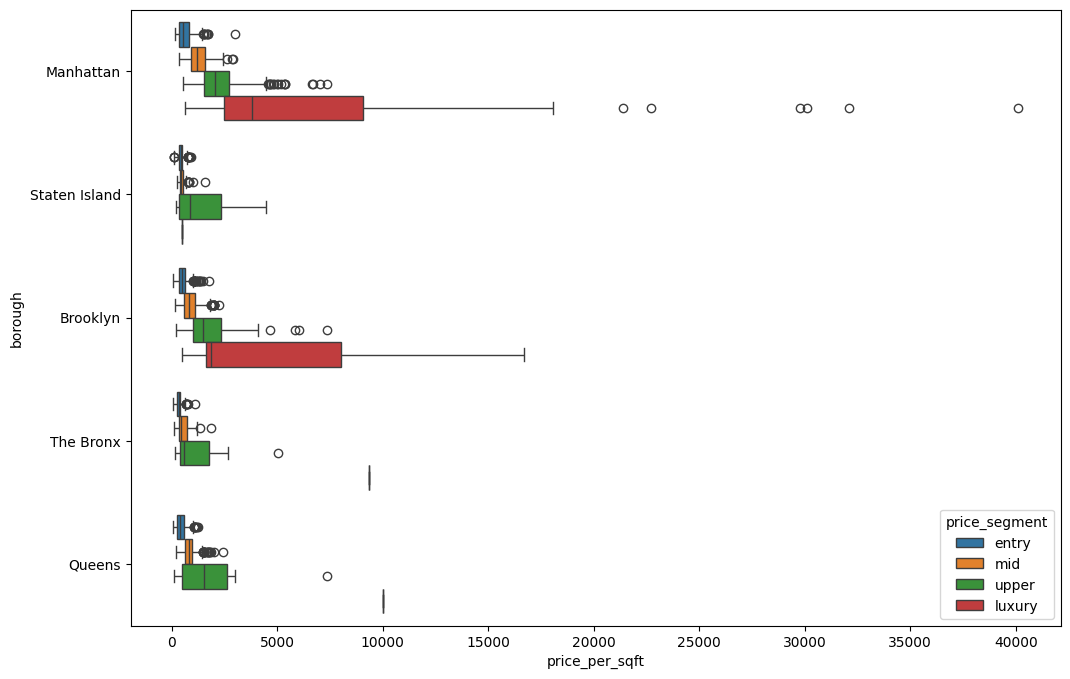

In [944]:
plt.figure(figsize=(12,8))
sns.boxplot(df, x='price_per_sqft', y='borough', hue='price_segment')

## Correlation

In [945]:
df.columns

Index(['brokertitle', 'type', 'price', 'beds', 'bath', 'propertysqft',
       'formatted_address', 'latitude', 'longitude', 'log_price',
       'price_segment', 'eda_type_clean', 'log_beds', 'beds_sqrt',
       'beds_asinh', 'beds_binned', 'log_bath', 'bath_binned', 'area_missing',
       'log_area', 'zip', 'borough', 'borough_Manhattan', 'borough_Brooklyn',
       'borough_Queens', 'price_per_sqft', 'log_pps'],
      dtype='object')

In [946]:
numerical_columns = ['price', 'beds', 'bath', 'propertysqft',
       'log_price','log_beds', 'log_bath',
       'log_area','price_per_sqft']

In [947]:
corr = df[numerical_columns].corr()

<Axes: >

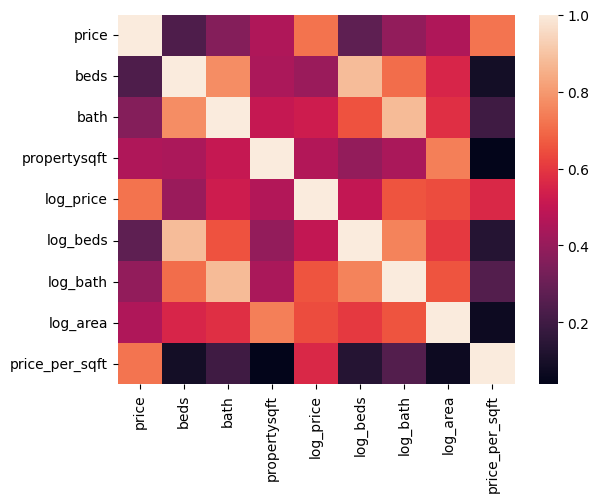

In [948]:
sns.heatmap(corr)

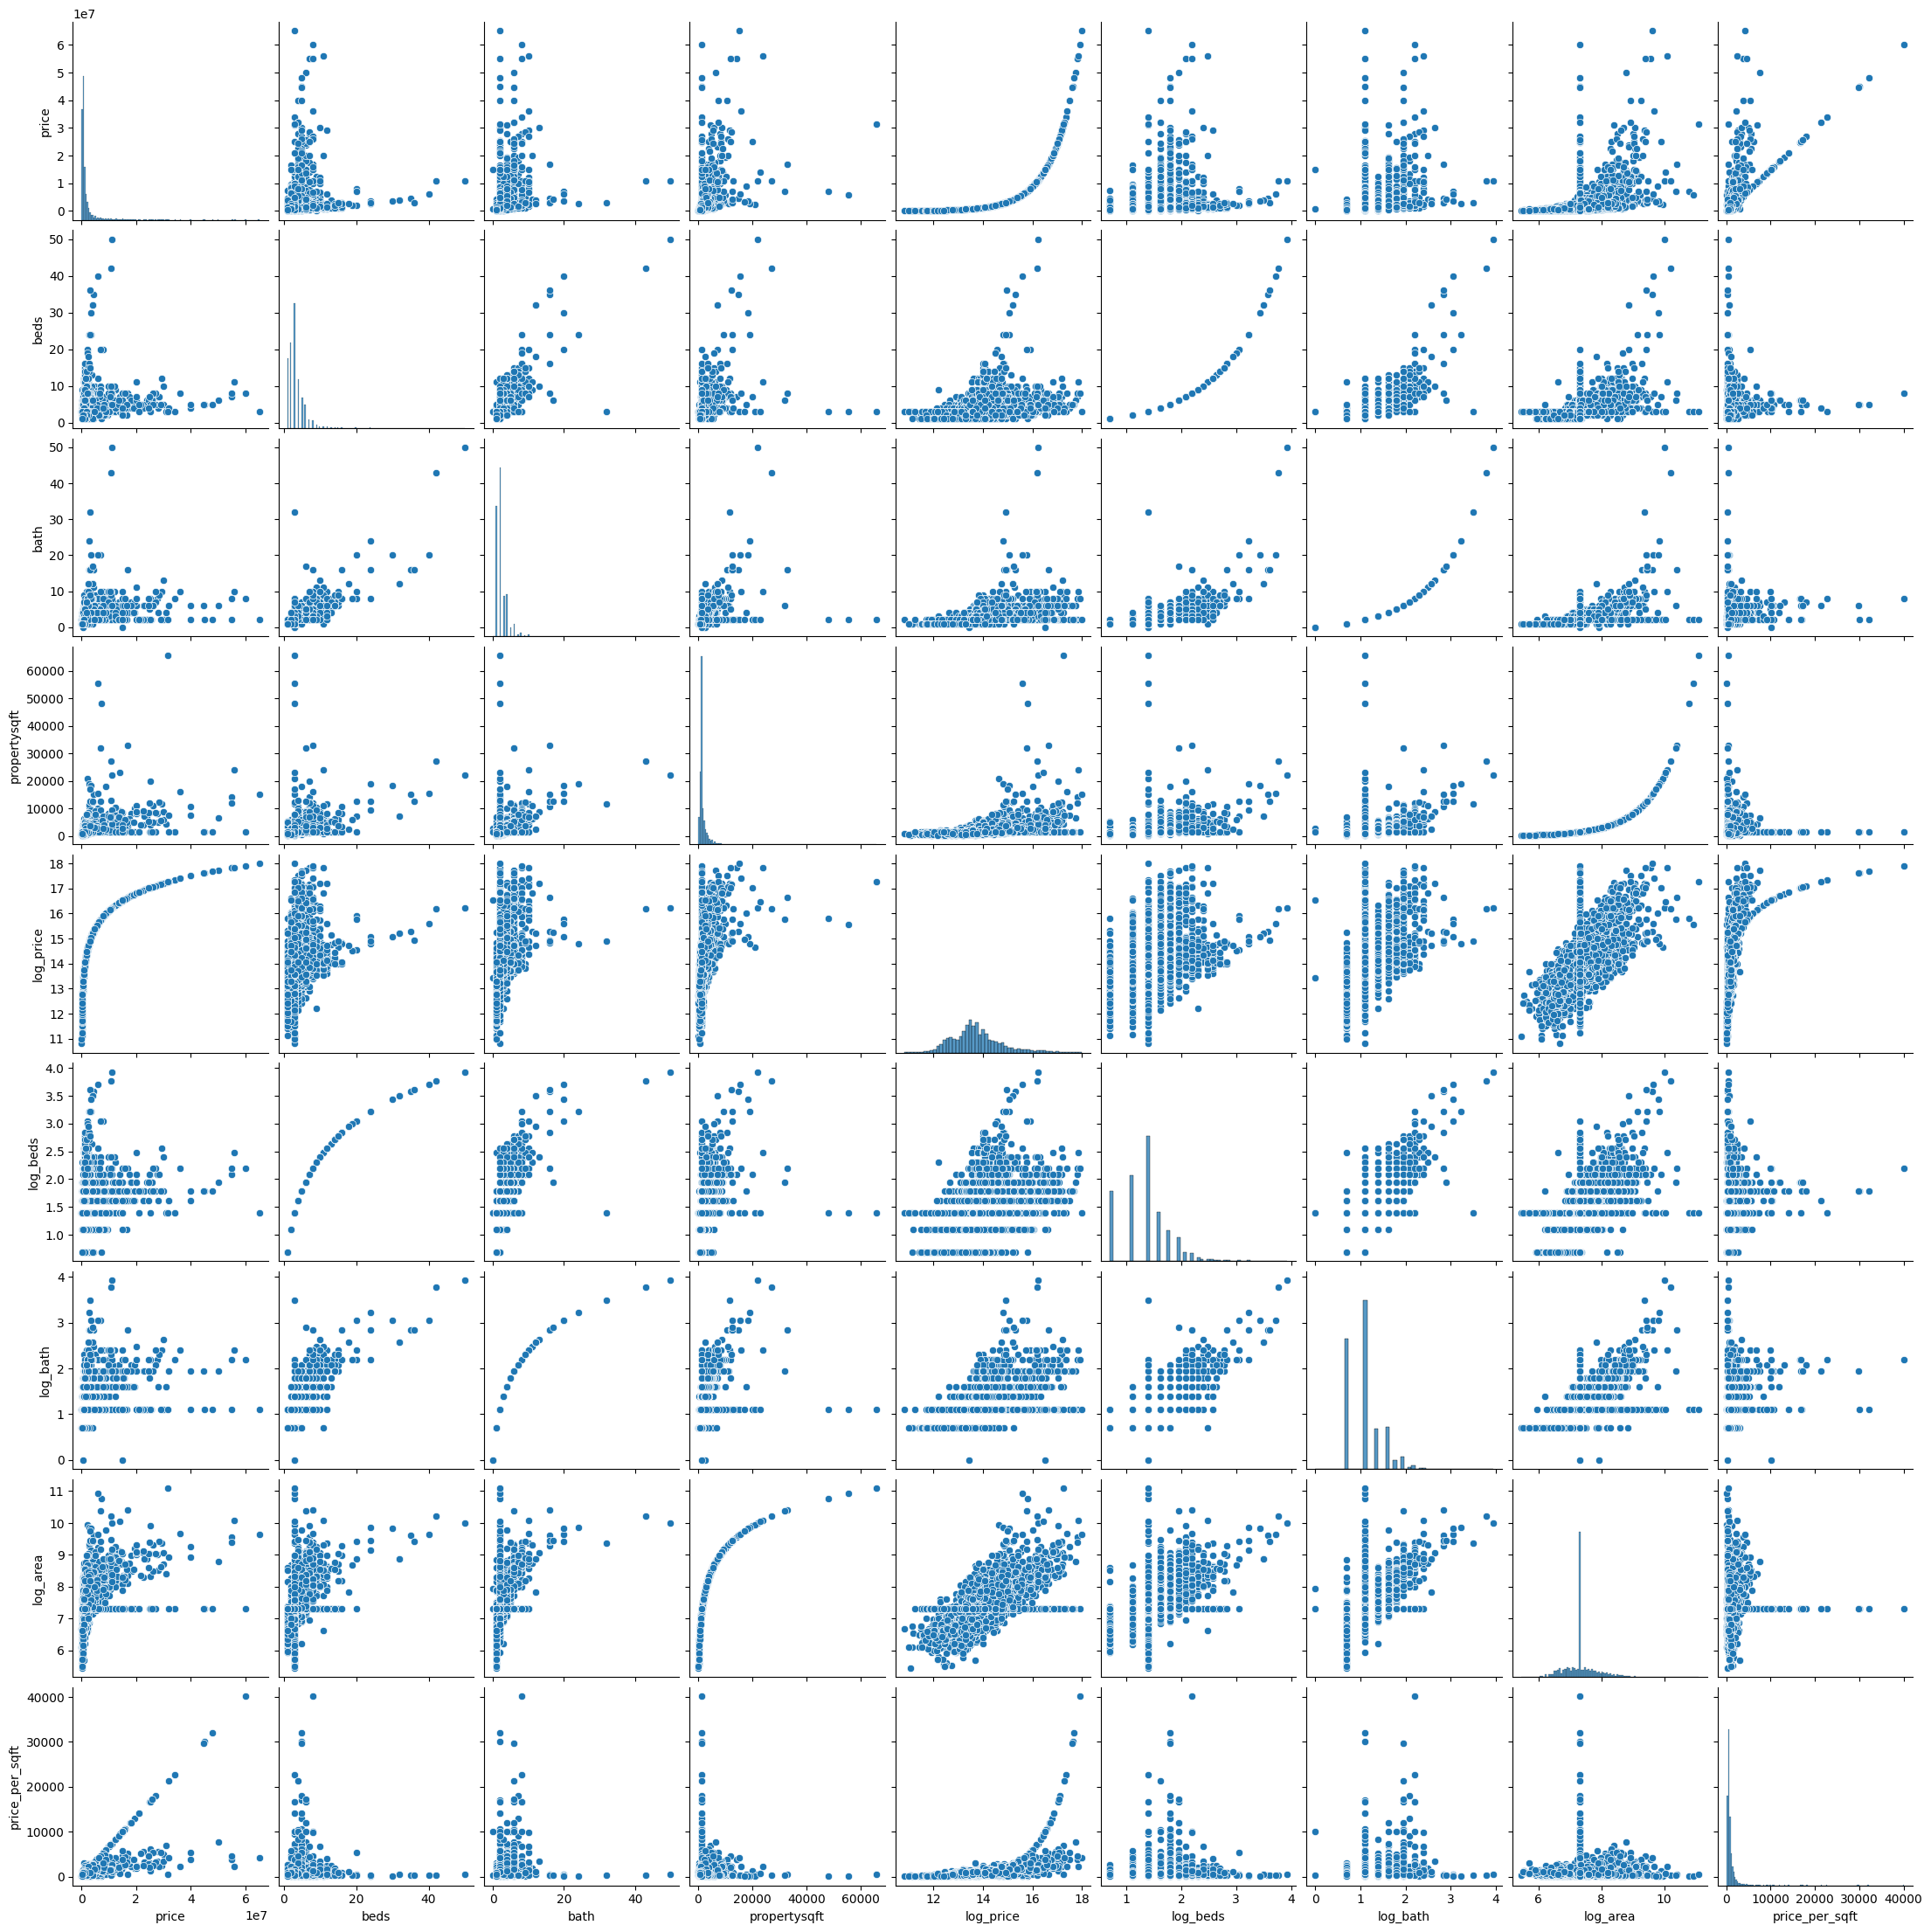

In [949]:
sns.pairplot(df[numerical_columns])

## Save edited dataset

In [951]:
df.to_csv('../data/processed/housing_cleaned.csv', index=False)